# Smile with Nhe: Complete Customer, Booking and Service Performance Analysis

This Colab/Jupyter notebook is a refreshable end-to-end analysis of the anonymised Smile with Nhe data from January 2022 to 20 September 2026.

It ingests every source file, profiles schemas and missingness, cleans and unifies the three booking systems, joins customers/payments/feedback/complaints/marketing/enquiries/reference data, measures demand/revenue/retention/operations, and produces more than 20 numbered visualisations plus evidence-based deductions.

Run all cells from top to bottom after uploading the complete project directory. If auto-discovery finds the wrong folder, set DATA_DIR in the configuration cell.

## Methodology and guardrails

- The three booking sources are unioned into a common schema. Legacy rows receive synthetic IDs because the hand-kept log has no booking ID.
- Test records, structural heading rows, blank records and rows labelled duplicate are flagged and excluded from headline metrics; they remain available in the raw objects and quality tables.
- Foreign amounts use the supplied monthly FX rates. Paystack amounts are converted from kobo to naira.
- Feedback is normalised to a common 0–10 scale: 1–5 scores are multiplied by 2 and 1–10 scores are retained.
- Paystack is a partial payment source because direct bank transfer, PayPal and Wise are not fully represented there. Booking-paid amounts and Paystack settlement diagnostics are kept separate.
- Acquisition source is interpreted as a first-booking attribute for customer acquisition analysis. The repeat-booking model uses first-booking features only and is descriptive, not causal.
- Exact booking joins are preferred; free-text references that cannot be safely matched are not force-matched.

In [ ]:
# 1. Imports and configuration
from pathlib import Path
from datetime import datetime, date
import json, re, os, sys, warnings, subprocess

_REQUIRED = {"matplotlib": "matplotlib", "seaborn": "seaborn", "sklearn": "scikit-learn", "statsmodels": "statsmodels", "plotly": "plotly", "openpyxl": "openpyxl"}
_missing = []
for _module, _package in _REQUIRED.items():
    try: __import__(_module)
    except ImportError: _missing.append(_package)
if _missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + _missing)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")
PALETTE, ACCENT, RED, BLUE, GREEN, PURPLE = "#0F766E", "#F59E0B", "#DC2626", "#2563EB", "#16A34A", "#7C3AED"
print("Python:", sys.version.split()[0], "| Pandas:", pd.__version__)

Python: 3.12.14 | Pandas: 3.0.6


In [ ]:
# 2. Discover the uploaded project directory
DATA_DIR = None  # Example: Path("/content/SmileWithNhe_Data 2")
AUTO_UPLOAD = True
from zipfile import ZipFile

EXPECTED_RELATIVE = {
    "Bookings_Log_2022-2023.xlsx": "01_bookings/Bookings_Log_2022-2023.xlsx",
    "Booking_Form_Responses_2024-01_to_2025-06.csv": "01_bookings/Booking_Form_Responses_2024-01_to_2025-06.csv",
    "booking_system_export_2025-07-01_to_2026-09-20.csv": "01_bookings/booking_system_export_2025-07-01_to_2026-09-20.csv",
    "paystack_transactions_2024-01-15_to_2026-09-20.csv": "02_payments/paystack_transactions_2024-01-15_to_2026-09-20.csv",
    "Customer_Register.xlsx": "03_customers/Customer_Register.xlsx",
    "feedback_responses.json": "04_feedback_and_complaints/feedback_responses.json",
    "complaints_log.csv": "04_feedback_and_complaints/complaints_log.csv",
    "Marketing_Spend_2022-2026.xlsx": "05_marketing/Marketing_Spend_2022-2026.xlsx",
    "social_media_monthly_stats.csv": "05_marketing/social_media_monthly_stats.csv",
    "whatsapp_dm_enquiries_2025-2026.csv": "05_marketing/whatsapp_dm_enquiries_2025-2026.csv",
    "staff_callers.csv": "06_reference/staff_callers.csv",
    "price_list_history.csv": "06_reference/price_list_history.csv",
    "fx_rates_used_by_business.csv": "06_reference/fx_rates_used_by_business.csv",
}

def discover_project_root(explicit=None):
    if explicit:
        p = Path(explicit).expanduser()
        if not p.exists(): raise FileNotFoundError(p)
        return p
    search_roots = [Path("/content"), Path.cwd(), Path("/kaggle/working"), Path("/mnt/data")]
    for root in search_roots:
        if not root.exists(): continue
        for candidate in [root] + [p for p in root.rglob("*") if p.is_dir()]:
            if (candidate / "01_bookings").exists() and (candidate / "README.md").exists():
                return candidate
    return None

PROJECT_ROOT = discover_project_root(DATA_DIR)
if PROJECT_ROOT is None:
    for root in [Path.cwd(), Path("/content"), Path("/mnt/data")]:
        if not root.exists(): continue
        for zip_path in root.glob("*.zip"):
            extract_dir = root / ("_extracted_" + zip_path.stem)
            extract_dir.mkdir(exist_ok=True)
            with ZipFile(zip_path) as zf: zf.extractall(extract_dir)
            PROJECT_ROOT = discover_project_root(extract_dir)
            if PROJECT_ROOT is not None: break
        if PROJECT_ROOT is not None: break

if PROJECT_ROOT is None and AUTO_UPLOAD and "google.colab" in sys.modules:
    from google.colab import files
    upload_dir = Path("/content/smile_with_nhe_upload")
    upload_dir.mkdir(exist_ok=True)
    uploaded = files.upload()
    for filename, payload in uploaded.items():
        target = upload_dir / Path(filename).name
        target.write_bytes(payload)
        if target.suffix.lower() == ".zip":
            with ZipFile(target) as zf: zf.extractall(upload_dir)
    PROJECT_ROOT = discover_project_root(upload_dir)
    if PROJECT_ROOT is None:
        for name, relative in EXPECTED_RELATIVE.items():
            matches = list(upload_dir.rglob(name))
            if matches:
                target = upload_dir / relative
                target.parent.mkdir(parents=True, exist_ok=True)
                target.write_bytes(matches[0].read_bytes())
        PROJECT_ROOT = discover_project_root(upload_dir)

if PROJECT_ROOT is None:
    raise FileNotFoundError("Upload/extract the project under /content or set DATA_DIR explicitly.")

OUTPUT_DIR = PROJECT_ROOT / "swn_analysis_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)

Project root: /Users/ghgfd/Downloads/SmileWithNhe_Data 2


In [ ]:
# 3. Load every raw source
def read_csv_safe(path, **kwargs):
    opts = {"low_memory": False}; opts.update(kwargs)
    for enc in ["utf-8", "utf-8-sig", "latin-1"]:
        try: return pd.read_csv(path, encoding=enc, **opts)
        except UnicodeDecodeError: pass
    return pd.read_csv(path, **opts)

paths = {
    "legacy": PROJECT_ROOT/"01_bookings/Bookings_Log_2022-2023.xlsx",
    "form": PROJECT_ROOT/"01_bookings/Booking_Form_Responses_2024-01_to_2025-06.csv",
    "system": PROJECT_ROOT/"01_bookings/booking_system_export_2025-07-01_to_2026-09-20.csv",
    "paystack": PROJECT_ROOT/"02_payments/paystack_transactions_2024-01-15_to_2026-09-20.csv",
    "customers": PROJECT_ROOT/"03_customers/Customer_Register.xlsx",
    "feedback": PROJECT_ROOT/"04_feedback_and_complaints/feedback_responses.json",
    "complaints": PROJECT_ROOT/"04_feedback_and_complaints/complaints_log.csv",
    "marketing": PROJECT_ROOT/"05_marketing/Marketing_Spend_2022-2026.xlsx",
    "social": PROJECT_ROOT/"05_marketing/social_media_monthly_stats.csv",
    "enquiries": PROJECT_ROOT/"05_marketing/whatsapp_dm_enquiries_2025-2026.csv",
    "staff": PROJECT_ROOT/"06_reference/staff_callers.csv",
    "prices": PROJECT_ROOT/"06_reference/price_list_history.csv",
    "fx": PROJECT_ROOT/"06_reference/fx_rates_used_by_business.csv",
}
missing = [str(p) for p in paths.values() if not p.exists()]
if missing: raise FileNotFoundError("Missing expected files:\n" + "\n".join(missing))

legacy_raw = pd.read_excel(paths["legacy"], sheet_name=None)
form_raw = read_csv_safe(paths["form"])
system_raw = read_csv_safe(paths["system"])
paystack_raw = read_csv_safe(paths["paystack"])
customer_sheets = pd.read_excel(paths["customers"], sheet_name=None)
customers_raw = customer_sheets["Customers"].copy()
corporate_raw = customer_sheets["Corporate Clients"].copy()
feedback_obj = json.loads(paths["feedback"].read_text(encoding="utf-8"))
feedback_raw = pd.json_normalize(feedback_obj["responses"])
complaints_raw = read_csv_safe(paths["complaints"])
marketing_sheets = pd.read_excel(paths["marketing"], sheet_name=None)
marketing_monthly = pd.read_excel(paths["marketing"], sheet_name="Monthly Spend", header=3)
social_raw = read_csv_safe(paths["social"])
enquiries_raw = read_csv_safe(paths["enquiries"])
staff_raw = read_csv_safe(paths["staff"])
prices_raw = read_csv_safe(paths["prices"])
fx_raw = read_csv_safe(paths["fx"])

raw_objects = {
    "legacy_2022": legacy_raw["2022"], "legacy_2023": legacy_raw["2023"], "legacy_jan_2024": legacy_raw["Jan 2024 (1-7)"],
    "form_bookings": form_raw, "system_bookings": system_raw, "paystack": paystack_raw,
    "customers": customers_raw, "corporate_clients": corporate_raw, "feedback": feedback_raw,
    "complaints": complaints_raw, "marketing_monthly_spend_raw": marketing_sheets["Monthly Spend"],
    "marketing_influencers": marketing_sheets["Influencer Campaigns"], "marketing_giveaways": marketing_sheets["Giveaways"],
    "social_stats": social_raw, "enquiries": enquiries_raw, "staff": staff_raw, "prices": prices_raw, "fx_rates": fx_raw
}
def profile(name, df):
    return {"source": name, "rows": len(df), "columns": df.shape[1], "whole_row_duplicates": int(df.duplicated().sum()),
            "missing_cells": int(df.isna().sum().sum()), "missing_pct_cells": float(df.isna().mean().mean())}
source_inventory = pd.DataFrame([profile(k, v) for k,v in raw_objects.items()]).sort_values("rows", ascending=False)
display(source_inventory)

,source,rows,columns,whole_row_duplicates,missing_cells,missing_pct_cells
14,enquiries,28867,12,0,39212,0.11
6,customers,24851,13,0,99003,0.31
5,paystack,22413,16,0,16728,0.05
4,system_bookings,19015,33,0,104847,0.17
8,feedback,15660,15,0,12263,0.05
3,form_bookings,15006,30,0,89248,0.20
1,legacy_2023,4804,16,46,9148,0.12
9,complaints,2508,12,0,874,0.03
0,legacy_2022,1725,15,39,2173,0.08
13,social_stats,205,11,0,140,0.06


In [ ]:
# 4. Schema, null and duplicate audit for every source
schema_rows = []
for name, df in raw_objects.items():
    for col in df.columns:
        schema_rows.append({"source":name, "column":str(col), "dtype":str(df[col].dtype),
                            "rows":len(df), "non_null":int(df[col].notna().sum()), "nulls":int(df[col].isna().sum()),
                            "null_pct":float(df[col].isna().mean()), "unique_non_null":int(df[col].nunique(dropna=True))})
schema_audit = pd.DataFrame(schema_rows).sort_values(["source","null_pct"], ascending=[True,False])
display(schema_audit.head(120))
print("Sources audited:", len(raw_objects), "| columns audited:", len(schema_audit))

,source,column,dtype,rows,non_null,nulls,null_pct,unique_non_null
168,complaints,Booking Ref,str,2508,1849,659,0.26,1849
170,complaints,Category,str,2508,2376,132,0.05,12
174,complaints,Date Resolved,str,2508,2425,83,0.03,972
165,complaints,Complaint ID,str,2508,2508,0,0.00,2508
166,complaints,Date Received,str,2508,2508,0,0.00,1175
167,complaints,Customer ID,str,2508,2508,0,0.00,2414
169,complaints,Channel,str,2508,2508,0,0.00,6
171,complaints,Description,str,2508,2508,0,0.00,609
172,complaints,Action Taken,str,2508,2508,0,0.00,9
173,complaints,Refund Amount,str,2508,2508,0,0.00,430


Sources audited: 18 | columns audited: 290


## 5. Cleaning utilities and reference tables

In [ ]:
# 5. Reusable parsers
MISSING = {"", "nan", "none", "null", "na", "n/a", "not available", "-"}
def clean_text(x):
    if pd.isna(x): return np.nan
    s = str(x).strip()
    return np.nan if s.lower() in MISSING else s

def parse_money(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().lower().replace(",", "")
    if s in MISSING: return np.nan
    if s in {"free","no charge","0","0.0"}: return 0.0
    m = re.search(r"[-+]?\d+(?:\.\d+)?", s)
    if not m: return np.nan
    v = float(m.group())
    if "k" in s: v *= 1000
    if re.search(r"\d\s*m(?:illion)?", s): v *= 1000000
    return v

def detect_currency(x, fallback="NGN"):
    if pd.isna(x): return fallback
    s = str(x).upper()
    if "£" in s or "GBP" in s: return "GBP"
    if "$" in s or "USD" in s: return "USD"
    if "CAD" in s: return "CAD"
    if "EUR" in s or "€" in s: return "EUR"
    if "AED" in s: return "AED"
    return "NGN"

def parse_date_value(x, ref=None, default_dayfirst=False, default_year=None):
    if pd.isna(x): return pd.NaT
    if isinstance(x, (pd.Timestamp, datetime, date)):
        # A time-only Excel value defaults to year 1. Re-anchor it to the row reference year.
        ts = pd.Timestamp(x)
        if ts.year == 1 and pd.notna(ref): ts = ts.replace(year=pd.Timestamp(ref).year)
        elif ts.year == 1 and default_year is not None: ts = ts.replace(year=int(default_year))
        return ts
    s = str(x).strip()
    if s.lower() in MISSING: return pd.NaT
    ref_year = pd.Timestamp(ref).year if pd.notna(ref) else default_year
    # Legacy sheets contain values such as 04-Jan and 3rd January without a year.
    s_clean = re.sub(r"(\d+)(st|nd|rd|th)\b", r"\1", s, flags=re.I)
    if not re.search(r"\b\d{4}\b", s_clean) and ref_year is not None:
        s_clean = f"{s_clean} {int(ref_year)}"
    c = []
    for dayfirst in [False, True]:
        d = pd.to_datetime(s_clean, errors="coerce", dayfirst=dayfirst, format="mixed")
        if pd.notna(d):
            d = pd.Timestamp(d)
            if getattr(d, "tzinfo", None): d = d.tz_localize(None)
            if d.normalize() not in [z.normalize() for z in c]: c.append(d)
    if not c: return pd.NaT
    if len(c) == 1 or pd.isna(ref): return c[1 if default_dayfirst and len(c)>1 else 0]
    ref = pd.Timestamp(ref)
    if getattr(ref, "tzinfo", None): ref = ref.tz_localize(None)
    return sorted(c, key=lambda d: (0 if 0 <= (d-ref).days <= 60 else 1 if 0 <= (d-ref).days <= 370 else 2, abs((d-ref).days)))[0]

def parse_dates(series, reference=None, default_dayfirst=False, default_year=None):
    if reference is None: return series.map(lambda x: parse_date_value(x, None, default_dayfirst, default_year))
    return pd.Series([parse_date_value(v, r, default_dayfirst, default_year) for v,r in zip(series, reference)], index=series.index)

def normalise_country(x):
    if pd.isna(x): return "Unknown"
    s = str(x).strip().lower()
    if s in {"ng","nigeria","nigerian"} or "nigeria" in s: return "Nigeria"
    if s in {"uk","u.k","united kingdom","england","britain"} or "kingdom" in s: return "United Kingdom"
    if s in {"us","usa","u.s.","united states","america"} or "united states" in s: return "United States"
    if s in {"ca","canada"}: return "Canada"
    if s in {"uae","united arab emirates"}: return "United Arab Emirates"
    return str(x).strip().title()

def normalise_source(x):
    if pd.isna(x) or str(x).strip().lower() in MISSING: return "Unknown"
    s = str(x).strip().lower()
    if any(k in s for k in ["return","old customer","existing","repeat","used you before"]): return "Returning"
    if any(k in s for k in ["instagram","insta","ig"]): return "Instagram"
    if "tiktok" in s: return "TikTok"
    if "whatsapp" in s: return "WhatsApp"
    if "facebook" in s or s == "fb": return "Facebook"
    if "influencer" in s: return "Influencer"
    if "referr" in s or "word of mouth" in s: return "Referral"
    if "google" in s or "search" in s: return "Google/Search"
    if "twitter" in s or s == "x": return "X/Twitter"
    if "linkedin" in s: return "LinkedIn"
    return "Other"

def normalise_service(x):
    if pd.isna(x): return "Unknown"
    s = str(x).strip().lower()
    if any(k in s for k in ["corporate","staff birthday","customer engagement","bulk"]): return "Corporate/Bulk"
    if "valentine" in s: return "Valentine"
    if "mother" in s: return "Mother's Day"
    if "father" in s: return "Father's Day"
    if "midnight" in s or "12am" in s: return "Midnight Birthday"
    if "song" in s or "singing" in s: return "Birthday with Song"
    if "birthday" in s or "bday" in s: return "Birthday Standard"
    if "anniversary" in s: return "Anniversary"
    if "appreciation" in s: return "Appreciation"
    if "congrat" in s: return "Congratulatory"
    if "prank" in s: return "Prank Surprise"
    if "wedding" in s: return "Wedding"
    if "apology" in s: return "Apology"
    if "get well" in s: return "Get Well Soon"
    if "voice note" in s: return "Voice Note"
    if "festive" in s or "new year" in s: return "Festive Greeting"
    if "condolence" in s: return "Condolence"
    if "proposal" in s: return "Proposal Assist"
    return "Other"

def normalise_status(x):
    if pd.isna(x): return "Unknown"
    s = str(x).strip().lower()
    if "duplicate" in s: return "Duplicate"
    if any(k in s for k in ["cancel","refund"]): return "Cancelled/Refunded"
    if any(k in s for k in ["unreach","failed","not reachable"]): return "Unreachable/Failed"
    if "partial" in s: return "Partially Completed"
    if any(k in s for k in ["complete","done","deliver","✅","rescheduled"]): return "Completed"
    if "scheduled" in s: return "Scheduled"
    return "Other"

def map_customer_id(x):
    if pd.isna(x): return np.nan
    s = str(x).strip()
    if s.upper().startswith("SWN-"): return s.upper()
    return old_to_new.get(s, s.upper() if s.upper().startswith("C") else np.nan)

def parse_feedback_ts(x):
    if pd.isna(x): return pd.NaT
    if isinstance(x, (int,float,np.integer,np.floating)):
        return pd.to_datetime(x, unit="ms" if abs(float(x))>1e11 else "s", errors="coerce", utc=True).tz_localize(None)
    return pd.to_datetime(x, errors="coerce", format="mixed", utc=True).tz_localize(None)

print("Utilities ready.")

Utilities ready.


In [ ]:
# 6. Reference cleaning
customers = customers_raw.copy()
customers.columns = [str(c).strip() for c in customers.columns]
customers["Customer ID"] = customers["Customer ID"].astype("string").str.strip()
customers["Old ID"] = customers["Old ID"].astype("string").str.strip()
customers["country_std"] = customers["Country"].map(normalise_country)
customers["city_std"] = customers["City"].astype("string").str.strip().str.title()
customers["customer_id_duplicate_flag"] = customers["Customer ID"].duplicated(keep=False)
customer_dim = customers.drop_duplicates("Customer ID", keep="first").copy()
old_to_new = (customers.dropna(subset=["Old ID","Customer ID"]).drop_duplicates("Old ID", keep="first").set_index("Old ID")["Customer ID"].to_dict())

staff = staff_raw.copy()
staff["start_date"] = pd.to_datetime(staff["start_date"], errors="coerce")
staff["end_date"] = pd.to_datetime(staff["end_date"], errors="coerce")
staff_dim = staff.sort_values(["caller_code","start_date"]).drop_duplicates("caller_code", keep="first")
staff_lookup = staff_dim.set_index("caller_code")["name"].to_dict()
staff_type_lookup = staff_dim.set_index("caller_code")["employment_type"].to_dict()

fx = fx_raw.copy()
fx["month_dt"] = pd.to_datetime(fx["month"].astype(str)+"-01", errors="coerce")
prices = prices_raw.copy()
prices["effective_from"] = pd.to_datetime(prices["effective_from"], errors="coerce")
prices["price_ngn_num"] = prices["price_ngn"].map(parse_money)
prices["service_group"] = prices["service"].map(normalise_service)
social = social_raw.copy()
social["month_dt"] = pd.to_datetime(social["month"].astype(str)+"-01", errors="coerce")
social["engagement_rate_pct"] = pd.to_numeric(social["engagement_rate"].astype("string").str.replace("%","",regex=False), errors="coerce")
influencers = marketing_sheets["Influencer Campaigns"].copy()
influencers["Date"] = pd.to_datetime(influencers["Date"], errors="coerce")
influencers["fee_ngn"] = influencers["Fee (₦)"].map(parse_money)
influencers["followers_num"] = influencers["Followers"].map(parse_money)
influencers["promo_code_std"] = influencers["Promo Code"].astype("string").str.strip().str.upper()
giveaways = marketing_sheets["Giveaways"].copy()
giveaways["month_dt"] = pd.to_datetime(giveaways["Month"], errors="coerce")
print("Customers:", customer_dim.shape, "| Staff rows:", len(staff), "| FX months:", fx.month_dt.min().date(), "to", fx.month_dt.max().date())

Customers: (24829, 16) | Staff rows: 20 | FX months: 2022-01-01 to 2026-09-01


## 6. Clean and unify the three booking sources

In [ ]:
# 7. Legacy Excel log
def clean_legacy(raw, sheet, year_tag):
    df = raw.dropna(how="all").reset_index(drop=True).copy()
    rename = ({"Date":"booking_raw","Customer":"customer_raw","Location":"city_raw","Service":"service_raw","Details":"occasion_raw","Call Date":"call_raw","Time":"time_raw","Amount":"amount_raw","Paid?":"payment_status_raw","Source":"source_raw","New/Old":"customer_type_raw","Caller":"caller_raw","Status":"status_raw","Remarks":"notes"}
              if sheet=="2022" else {"Date Booked":"booking_raw","Customer ID":"customer_raw","Location":"city_raw","Service":"service_raw","Occasion / Details":"occasion_raw","Call Date":"call_raw","Time":"time_raw","Amount (₦)":"amount_raw","Payment":"payment_status_raw","How they found us":"source_raw","Customer Type":"customer_type_raw","Caller":"caller_raw","Status":"status_raw","Rating":"rating_raw","Remarks":"notes"})
    df = df.rename(columns=rename)
    for c in ["booking_raw","customer_raw","city_raw","service_raw","occasion_raw","call_raw","time_raw","amount_raw","payment_status_raw","source_raw","customer_type_raw","caller_raw","status_raw","rating_raw","notes"]:
        if c not in df: df[c] = np.nan
    df["source_system"], df["source_sheet"], df["source_row"] = "legacy_excel", sheet, np.arange(2,len(df)+2)
    df["is_test"] = df.astype(str).apply(lambda r: r.str.contains("test|testing|ignore",case=False,regex=True).any(),axis=1)
    df["is_structural_row"] = df[["booking_raw","customer_raw","service_raw"]].isna().all(axis=1)
    df["booking_date"] = parse_dates(df["booking_raw"], default_dayfirst=True, default_year=int(year_tag[:4]))
    df["call_date"] = parse_dates(df["call_raw"], reference=df["booking_date"], default_dayfirst=True)
    df["booking_id"] = [f"LEG-{year_tag}-{i:06d}" for i in df.source_row]
    df["customer_id_raw"] = df.customer_raw.map(clean_text); df["customer_id"] = df.customer_id_raw.map(map_customer_id)
    df["city"] = df.city_raw.map(clean_text); df["country"] = df.city.map(normalise_country)
    df["service_name"] = df.service_raw.map(clean_text); df["service_group"] = df.service_name.map(normalise_service)
    df["amount_local"] = df.amount_raw.map(parse_money); df["currency"] = df.amount_raw.map(detect_currency)
    df["list_price_local"], df["discount_amount_local"], df["qty"] = df["amount_local"], np.nan, 1.0
    df["acquisition_source_raw"] = df.source_raw; df["acquisition_source"] = df.source_raw.map(normalise_source)
    df["customer_segment"] = df.customer_type_raw.astype("string").str.lower().map(lambda x: "Corporate" if pd.notna(x) and any(k in x for k in ["corporate","company","business"]) else "Individual")
    df["payment_channel"] = df.payment_status_raw.map(clean_text); df["payment_status"] = df.payment_status_raw.map(clean_text); df["payment_reference"] = np.nan
    df["caller_raw"] = df.caller_raw.map(clean_text); df["caller_name"], df["caller_code"] = df["caller_raw"], np.nan
    df["status_raw_clean"] = df.status_raw.map(clean_text); df["status"] = df.status_raw.map(normalise_status); df["completed_flag"] = df.status.eq("Completed")
    df["rating_10"] = pd.to_numeric(df.rating_raw, errors="coerce")*2; df["notes_clean"] = df.notes.map(clean_text); df["is_duplicate_status"] = False; df["is_structural_row"] = df["is_structural_row"].fillna(False)
    return df
legacy_clean = pd.concat([clean_legacy(legacy_raw["2022"],"2022","2022"),clean_legacy(legacy_raw["2023"],"2023","2023"),clean_legacy(legacy_raw["Jan 2024 (1-7)"],"Jan 2024 (1-7)","2024")],ignore_index=True)
print("Legacy rows:",len(legacy_clean),"| structural:",int(legacy_clean.is_structural_row.sum()),"| test:",int(legacy_clean.is_test.sum()))

Legacy rows: 6639 | structural: 33 | test: 2


In [ ]:
# 8. Google Form responses
form = form_raw.copy()
form["booking_date"] = pd.to_datetime(form["Timestamp"],errors="coerce",format="mixed")
form["call_date"] = parse_dates(form["Call Date"],reference=form["booking_date"])
form["source_system"], form["source_sheet"], form["source_row"] = "google_form","form_csv",np.arange(2,len(form)+2)
form["is_test"] = form.astype(str).apply(lambda r:r.str.contains("test|testing|ignore",case=False,regex=True).any(),axis=1)
form["is_duplicate_status"] = form["Call Status"].astype("string").str.contains("duplicate",case=False,na=False)
form["is_structural_row"] = False
form["booking_id"] = form["Booking ID"].astype("string").str.strip().fillna(pd.Series([f"FORM-MISSING-{i:06d}" for i in form.index],index=form.index))
form["customer_id_raw"] = form["Customer ID"].map(clean_text); form["customer_id"] = form.customer_id_raw.map(map_customer_id)
form["city"] = form.City.map(clean_text); form["country"] = form["State/Country"].map(normalise_country)
form["service_name"] = form.Service.map(clean_text); form["service_group"] = form.service_name.map(normalise_service)
form["amount_local"] = form["Amount Paid"].map(parse_money); form["currency"] = form.Currency.fillna("NGN").astype("string").str.upper()
form["list_price_local"] = form["Price (NGN)"].map(parse_money); form["discount_amount_local"] = form.Discount.map(parse_money)
form["qty"] = pd.to_numeric(form.Qty,errors="coerce").fillna(1); form["acquisition_source_raw"] = form["How did you hear about us?"]; form["acquisition_source"] = form.acquisition_source_raw.map(normalise_source)
form["customer_segment"] = form["Customer Type"].astype("string").str.lower().map(lambda x:"Corporate" if pd.notna(x) and any(k in x for k in ["corporate","company","business"]) else "Individual")
form["payment_channel"] = form["Payment Method"].map(clean_text); form["payment_status"] = np.where(form["Payment Method"].notna(),"Paid/Recorded","Unknown"); form["payment_reference"] = form["Payment Reference"].map(clean_text)
form["caller_name"] = form["Assigned Caller"].astype("string").str.replace(r"\s*\(.*?\)","",regex=True).str.strip(); form["caller_code"] = np.nan
form["status_raw_clean"] = form["Call Status"].map(clean_text); form["status"] = form["Call Status"].map(normalise_status); form["completed_flag"] = form.status.eq("Completed")
form["rating_10"] = pd.to_numeric(form["Rating (1-5)"],errors="coerce")*2; form["notes_clean"] = form.Notes.map(clean_text)
form_clean=form
print("Form rows:",len(form_clean),"| test:",int(form_clean.is_test.sum()),"| duplicate labels:",int(form_clean.is_duplicate_status.sum()))

Form rows: 15006 | test: 62 | duplicate labels: 130


In [ ]:
# 9. Booking-system export
system = system_raw.copy()
system["booking_date"] = pd.to_datetime(system.created_at,errors="coerce",format="mixed",utc=True).dt.tz_localize(None)
system["call_date"] = pd.to_datetime(system.scheduled_at,errors="coerce",format="mixed")
system["source_system"], system["source_sheet"], system["source_row"] = "booking_system","system_csv",np.arange(2,len(system)+2)
system["is_test"] = system.astype(str).apply(lambda r:r.str.contains("test|ignore",case=False,regex=True).any(),axis=1); system["is_duplicate_status"] = False; system["is_structural_row"] = False
system["booking_id"] = system.booking_id.astype("string").str.strip(); system["customer_id_raw"] = system.customer_id.map(clean_text); system["customer_id"] = system.customer_id_raw.map(map_customer_id)
system["city"] = system.city.map(clean_text); system["country"] = system.country.map(normalise_country); system["service_name"] = system.service_name.map(clean_text); system["service_group"] = system.service_name.map(normalise_service)
system["amount_local"] = pd.to_numeric(system.total_paid,errors="coerce"); system["currency"] = system.currency.astype("string").str.upper(); system["list_price_local"] = pd.to_numeric(system.list_price,errors="coerce"); system["discount_amount_local"] = pd.to_numeric(system.discount_amount,errors="coerce"); system["qty"] = pd.to_numeric(system.qty,errors="coerce").fillna(1)
system["acquisition_source_raw"] = system.acquisition_source; system["acquisition_source"] = system.acquisition_source_raw.map(normalise_source); system["customer_segment"] = system.customer_segment.astype("string").str.title().fillna("Individual")
system["payment_channel"] = system.payment_channel.map(clean_text); system["payment_status"] = system.payment_status.map(clean_text); system["payment_reference"] = system.payment_reference.map(clean_text)
system["caller_code"] = system.caller_code.map(clean_text); system["caller_name"] = system.caller_code.map(staff_lookup); system["status_raw_clean"] = system.status.map(clean_text); system["status"] = system.status.map(normalise_status); system["completed_flag"] = system.status.eq("Completed")
system["rating_10"] = pd.to_numeric(system.feedback_score,errors="coerce"); system["notes_clean"] = system.notes.map(clean_text); system_clean=system
print("System rows:",len(system_clean),"| test:",int(system_clean.is_test.sum()))

System rows: 19015 | test: 6


In [ ]:
# 10. Union, convert currencies and enrich bookings
common = ["booking_id","booking_date","call_date","customer_id_raw","customer_id","customer_segment","city","country","service_name","service_group","qty","amount_local","currency","list_price_local","discount_amount_local","payment_channel","payment_status","payment_reference","acquisition_source_raw","acquisition_source","caller_raw","caller_code","caller_name","status","status_raw_clean","completed_flag","rating_10","notes_clean","source_system","source_sheet","source_row","is_test","is_duplicate_status","is_structural_row"]
for df in [legacy_clean,form_clean,system_clean]:
    for c in common:
        if c not in df: df[c]=np.nan
bookings_all=pd.concat([legacy_clean[common],form_clean[common],system_clean[common]],ignore_index=True)
bookings_all["booking_date"]=pd.to_datetime(bookings_all.booking_date,errors="coerce"); bookings_all["call_date"]=pd.to_datetime(bookings_all.call_date,errors="coerce")
bookings_all["booking_month"]=bookings_all.booking_date.dt.to_period("M").dt.to_timestamp(); bookings_all["currency"]=bookings_all.currency.fillna("NGN").astype("string").str.upper()
fx_long=fx.melt(id_vars=["month","month_dt"],var_name="currency",value_name="ngn_per_unit"); fx_long["currency"]=fx_long.currency.str.replace("NGN_per_","",regex=False)
bookings_all=bookings_all.merge(fx_long[["month_dt","currency","ngn_per_unit"]],left_on=["booking_month","currency"],right_on=["month_dt","currency"],how="left")
bookings_all["currency_rate_missing_flag"]=bookings_all.currency.ne("NGN") & bookings_all.ngn_per_unit.isna(); bookings_all["ngn_per_unit"]=bookings_all.ngn_per_unit.fillna(1)
bookings_all["amount_paid_ngn"]=bookings_all.amount_local*bookings_all.ngn_per_unit; bookings_all["list_price_ngn"]=bookings_all.list_price_local*bookings_all.ngn_per_unit; bookings_all["discount_ngn"]=bookings_all.discount_amount_local*bookings_all.ngn_per_unit
bookings_all["amount_missing_flag"]=bookings_all.amount_paid_ngn.isna()
price_matches=[]
for _svc, _left in bookings_all.groupby("service_group"):
    _right=prices.loc[(prices.service_group==_svc)&prices.effective_from.notna()&prices.price_ngn_num.notna(),["effective_from","price_ngn_num"]].sort_values("effective_from")
    _left=_left.loc[_left.booking_date.notna(),["booking_id","booking_date"]].sort_values("booking_date")
    if len(_left) and len(_right):
        _m=pd.merge_asof(_left,_right,left_on="booking_date",right_on="effective_from",direction="backward")
        price_matches.append(_m[["booking_id","price_ngn_num"]])
price_reference=pd.concat(price_matches,ignore_index=True).rename(columns={"price_ngn_num":"price_reference_ngn"}) if price_matches else pd.DataFrame(columns=["booking_id","price_reference_ngn"])
bookings_all=bookings_all.merge(price_reference,on="booking_id",how="left")
bookings_all["is_valid_analysis_row"]=~(bookings_all.is_test.fillna(False)|bookings_all.is_duplicate_status.fillna(False)|bookings_all.is_structural_row.fillna(False)|bookings_all.booking_id.isna())
bookings_all["caller_name"]=bookings_all.caller_name.fillna(bookings_all.caller_raw).astype("string").str.replace(r"\s*\(.*?\)","",regex=True).str.strip(); bookings_all["staff_type"]=bookings_all.caller_code.map(staff_type_lookup)
bookings_all["city_std"]=bookings_all.city.astype("string").str.strip().str.title(); bookings_all["country_std"]=bookings_all.country.map(normalise_country)
bookings=bookings_all.loc[bookings_all.is_valid_analysis_row].copy().sort_values(["customer_id","booking_date","booking_id"]).reset_index(drop=True)
bookings["booking_number"]=bookings.groupby("customer_id",dropna=False).cumcount()+1; bookings["is_repeat_booking"]=bookings.booking_number.gt(1)&bookings.customer_id.notna(); bookings["customer_first_booking_flag"]=bookings.booking_number.eq(1)&bookings.customer_id.notna()
bookings["day_of_week"]=bookings.call_date.fillna(bookings.booking_date).dt.day_name(); bookings["month_num"]=bookings.call_date.fillna(bookings.booking_date).dt.month; bookings["year"]=bookings.booking_date.dt.year
customer_enrich=customer_dim[["Customer ID","Gender","Age Range","country_std","city_std","How They Found Us","WhatsApp Broadcast","Customer Since"]].rename(columns={"Customer ID":"customer_id","country_std":"register_country","city_std":"register_city","How They Found Us":"register_source"})
bookings=bookings.merge(customer_enrich,on="customer_id",how="left")
paystack=paystack_raw.copy(); paystack["amount_ngn"]=pd.to_numeric(paystack.amount,errors="coerce")/100; paystack["fees_ngn"]=pd.to_numeric(paystack.fees,errors="coerce")/100
paystack_summary=paystack.groupby("reference").agg(paystack_txn_count=("reference","size"),paystack_success_count=("status",lambda s:int((s=="success").sum())),paystack_amount_ngn=("amount_ngn",lambda s:float(paystack.loc[s.index].loc[paystack.loc[s.index,"status"].eq("success"),"amount_ngn"].sum())),paystack_fees_ngn=("fees_ngn",lambda s:float(paystack.loc[s.index].loc[paystack.loc[s.index,"status"].eq("success"),"fees_ngn"].sum()))).reset_index().rename(columns={"reference":"payment_reference"})
bookings=bookings.merge(paystack_summary,on="payment_reference",how="left")
print("All unified rows:",len(bookings_all),"| headline rows:",len(bookings),"| date range:",bookings.booking_date.min().date(),"to",bookings.booking_date.max().date())

All unified rows: 40660 | headline rows: 40487 | date range: 2022-01-03 to 2026-09-20


In [ ]:
# 11. Feedback, complaints, enquiries and marketing joins
feedback=feedback_raw.copy(); feedback["submitted_dt"]=feedback.submitted_at.map(parse_feedback_ts); feedback["feedback_scale"]=feedback.scale.astype("string"); feedback["overall_raw"]=pd.to_numeric(feedback.get("scores.overall"),errors="coerce"); feedback["overall_10"]=np.where(feedback.feedback_scale.eq("1-5"),feedback.overall_raw*2,feedback.overall_raw)
feedback["booking_ref_clean"]=feedback.booking_ref.map(clean_text); feedback["customer_id_std"]=feedback.customer_id.map(map_customer_id) if "customer_id" in feedback else np.nan; feedback["exact_booking_id"]=feedback.booking_ref_clean.where(feedback.booking_ref_clean.astype("string").str.match(r"^(BK-|B\d+)",na=False))
feedback_booking_agg=feedback.dropna(subset=["exact_booking_id"]).groupby("exact_booking_id").agg(feedback_count=("response_id","nunique"),feedback_score_10=("overall_10","mean")).reset_index().rename(columns={"exact_booking_id":"booking_id"})
feedback_customer_agg=feedback.dropna(subset=["customer_id_std"]).groupby("customer_id_std").agg(customer_feedback_count=("response_id","nunique"),customer_feedback_score_10=("overall_10","mean")).reset_index().rename(columns={"customer_id_std":"customer_id"})
bookings=bookings.merge(feedback_booking_agg,on="booking_id",how="left").merge(feedback_customer_agg,on="customer_id",how="left")
complaints=complaints_raw.copy(); complaints["date_received"]=pd.to_datetime(complaints["Date Received"],errors="coerce",dayfirst=True); complaints["refund_amount_ngn"]=complaints["Refund Amount"].map(parse_money); complaints["booking_id_clean"]=complaints["Booking Ref"].map(clean_text)
complaint_agg=complaints.dropna(subset=["booking_id_clean"]).groupby("booking_id_clean").agg(complaint_count=("Complaint ID","nunique"),complaint_refund_ngn=("refund_amount_ngn","sum")).reset_index().rename(columns={"booking_id_clean":"booking_id"})
bookings=bookings.merge(complaint_agg,on="booking_id",how="left"); bookings["complaint_count"]=bookings.complaint_count.fillna(0); bookings["has_complaint"]=bookings.complaint_count.gt(0)
enquiries=enquiries_raw.copy(); enquiries["received_dt"]=pd.to_datetime(enquiries.received_at,errors="coerce",format="mixed")
enq_agg=enquiries.dropna(subset=["booking_id"]).groupby("booking_id").agg(enquiry_count=("enquiry_id","nunique"),enquiry_outcome=("outcome","first"),enquiry_platform=("first_contact_platform","first")).reset_index()
bookings=bookings.merge(enq_agg,on="booking_id",how="left")
spend=marketing_monthly.copy(); spend.columns=[str(c).strip() for c in spend.columns]; spend=spend.rename(columns={spend.columns[0]:"channel_item"}); spend=spend.iloc[1:] if str(spend.iloc[0].channel_item).lower().startswith("channel") else spend; spend=spend[spend.channel_item.notna()]
spend_long=spend.melt(id_vars=["channel_item"],var_name="month_label",value_name="spend_raw"); spend_long["month_dt"]=pd.to_datetime(spend_long.month_label,format="%b-%y",errors="coerce"); spend_long["spend_ngn"]=spend_long.spend_raw.map(parse_money); spend_long["unparsed_flag"]=spend_long.spend_raw.notna()&spend_long.spend_ngn.isna(); spend_long["spend_ngn"]=spend_long.spend_ngn.fillna(0)
spend_monthly=spend_long.groupby("month_dt",as_index=False).agg(marketing_spend_ngn=("spend_ngn","sum"),unparsed_spend_cells=("unparsed_flag","sum"))
monthly_kpis=bookings.assign(month_dt=bookings.booking_date.dt.to_period("M").dt.to_timestamp()).groupby("month_dt",as_index=False).agg(bookings=("booking_id","nunique"),paid_revenue_ngn=("amount_paid_ngn","sum"),completed_bookings=("completed_flag","sum")).merge(spend_monthly,on="month_dt",how="outer").sort_values("month_dt")
monthly_kpis[["bookings","paid_revenue_ngn","marketing_spend_ngn"]]=monthly_kpis[["bookings","paid_revenue_ngn","marketing_spend_ngn"]].fillna(0); monthly_kpis["cost_per_booking_ngn"]=monthly_kpis.marketing_spend_ngn.div(monthly_kpis.bookings.replace(0,np.nan))
print("Feedback:",len(feedback),"| Complaints:",len(complaints),"| Enquiries:",len(enquiries),"| Converted enquiries:",int(enquiries.outcome.eq("Booked").sum()))

Feedback: 15660 | Complaints: 2508 | Enquiries: 28867 | Converted enquiries: 15604


In [ ]:
# 12. Data quality and join coverage
quality_summary=pd.DataFrame({"metric":["Unified rows before exclusions","Headline rows","Excluded test rows","Excluded structural rows","Excluded duplicate-labelled rows","Headline missing customer ID","Headline missing booking date","Headline missing amount","Headline missing FX rate","Customer-register duplicate IDs","Feedback 1-5 scale","Feedback 1-10 scale","Paystack transactions","Paystack successes","Complaints","Enquiries"],
"value":[len(bookings_all),len(bookings),int(bookings_all.is_test.fillna(False).sum()),int(bookings_all.is_structural_row.fillna(False).sum()),int(bookings_all.is_duplicate_status.fillna(False).sum()),int(bookings.customer_id.isna().sum()),int(bookings.booking_date.isna().sum()),int(bookings.amount_missing_flag.sum()),int(bookings.currency_rate_missing_flag.sum()),int(customers.customer_id_duplicate_flag.sum()),int(feedback.feedback_scale.eq("1-5").sum()),int(feedback.feedback_scale.eq("1-10").sum()),len(paystack),int(paystack.status.eq("success").sum()),len(complaints),len(enquiries)]})
display(quality_summary)
join_coverage=pd.DataFrame([
{"join":"Bookings -> customer register","matched":int(bookings.register_city.notna().sum()),"eligible":int(bookings.customer_id.notna().sum())},
{"join":"Bookings -> Paystack","matched":int(bookings.paystack_txn_count.notna().sum()),"eligible":int(bookings.payment_reference.notna().sum())},
{"join":"Bookings -> exact feedback","matched":int(bookings.feedback_count.notna().sum()),"eligible":len(bookings)},
{"join":"Bookings -> exact complaints","matched":int(bookings.has_complaint.sum()),"eligible":len(bookings)},
{"join":"Bookings -> enquiry","matched":int(bookings.enquiry_count.notna().sum()),"eligible":len(bookings)},{"join":"Bookings -> price history","matched":int(bookings.price_reference_ngn.notna().sum()),"eligible":int(bookings.booking_date.notna().sum())}])
join_coverage["match_rate"]=join_coverage.matched/join_coverage.eligible.replace(0,np.nan); display(join_coverage)
display(bookings.isna().mean().sort_values(ascending=False).head(18).rename("null_pct").to_frame())

,metric,value
0,Unified rows before exclusions,40660
1,Headline rows,40487
2,Excluded test rows,70
3,Excluded structural rows,33
4,Excluded duplicate-labelled rows,130
5,Headline missing customer ID,119
6,Headline missing booking date,0
7,Headline missing amount,131
8,Headline missing FX rate,0
9,Customer-register duplicate IDs,44


,join,matched,eligible,match_rate
0,Bookings -> customer register,37687,40368,0.93
1,Bookings -> Paystack,19605,20897,0.94
2,Bookings -> exact feedback,13239,40487,0.33
3,Bookings -> exact complaints,1849,40487,0.05
4,Bookings -> enquiry,15604,40487,0.39
5,Bookings -> price history,39552,40487,0.98


,null_pct
complaint_refund_ngn,0.95
month_dt,0.94
Customer Since,0.86
notes_clean,0.85
caller_raw,0.84
rating_10,0.68
feedback_score_10,0.67
feedback_count,0.67
enquiry_platform,0.61
enquiry_count,0.61


## 7. KPI overview

In [ ]:
# 13. KPI tables
completed=bookings.status.eq("Completed")
customer_level=bookings.dropna(subset=["customer_id"]).groupby("customer_id").agg(bookings=("booking_id","nunique"),first_booking=("booking_date","min"),total_paid_ngn=("amount_paid_ngn","sum"),first_source=("acquisition_source","first"),first_service=("service_group","first"),country=("country_std","first")).reset_index()
customer_level["is_repeat_customer"]=customer_level.bookings.gt(1); customer_level["cohort_month"]=customer_level.first_booking.dt.to_period("M").dt.to_timestamp()
kpis=pd.Series({"Total headline bookings":len(bookings),"Completed bookings":int(completed.sum()),"Completion rate":completed.mean(),"Unique identified customers":len(customer_level),"Repeat customers":int(customer_level.is_repeat_customer.sum()),"Repeat-customer rate":customer_level.is_repeat_customer.mean(),"Parsed paid revenue (NGN)":bookings.amount_paid_ngn.sum(),"Median booking value (NGN)":bookings.amount_paid_ngn.median(),"Average feedback /10":feedback.overall_10.mean(),"Enquiry conversion rate":enquiries.outcome.eq("Booked").mean(),"Complaint rate per booking":bookings.has_complaint.mean()}).to_frame("value")
display(kpis); display(bookings.service_group.value_counts().head(15).rename("bookings").to_frame()); display(bookings.acquisition_source.value_counts().head(15).rename("bookings").to_frame())

,value
Total headline bookings,"40,487.00"
Completed bookings,"37,752.00"
Completion rate,0.93
Unique identified customers,"24,306.00"
Repeat customers,"8,443.00"
Repeat-customer rate,0.35
Parsed paid revenue (NGN),"1,481,136,702.50"
Median booking value (NGN),"8,250.00"
Average feedback /10,8.35
Enquiry conversion rate,0.54


,bookings
service_group,
Birthday Standard,15566
Birthday with Song,6345
Midnight Birthday,2841
Anniversary,2712
Congratulatory,2672
Appreciation,2545
Prank Surprise,1150
Other,1028
Corporate/Bulk,909


,bookings
acquisition_source,
Returning,10077
Instagram,8333
Unknown,4605
TikTok,4207
WhatsApp,3621
Referral,3318
Other,3299
Facebook,1381
Influencer,670


## 8. Demand, revenue and service mix visualisations (Plots 1–12)

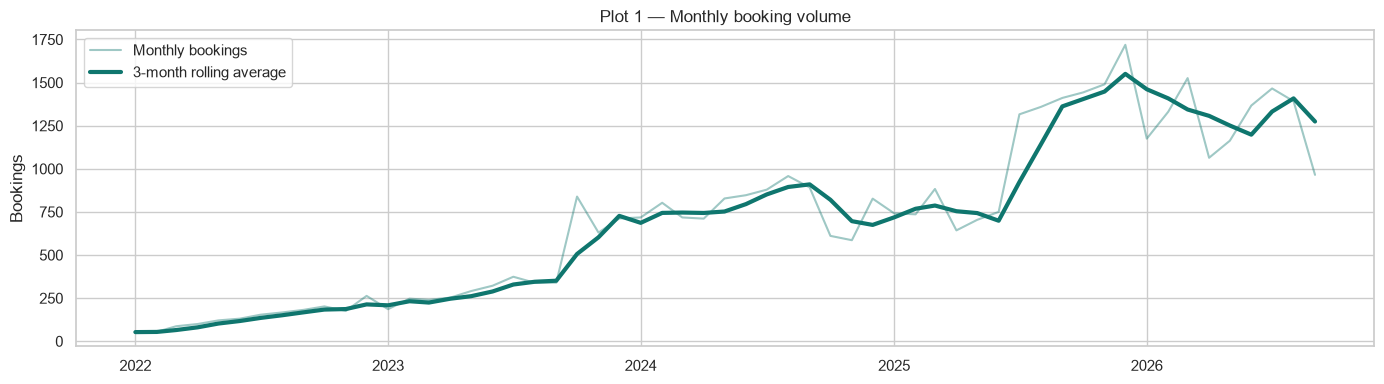

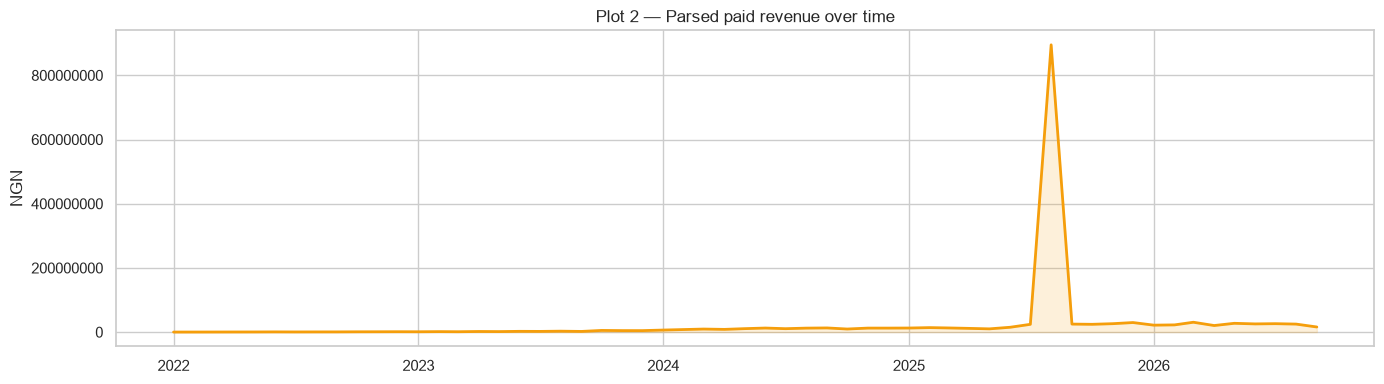

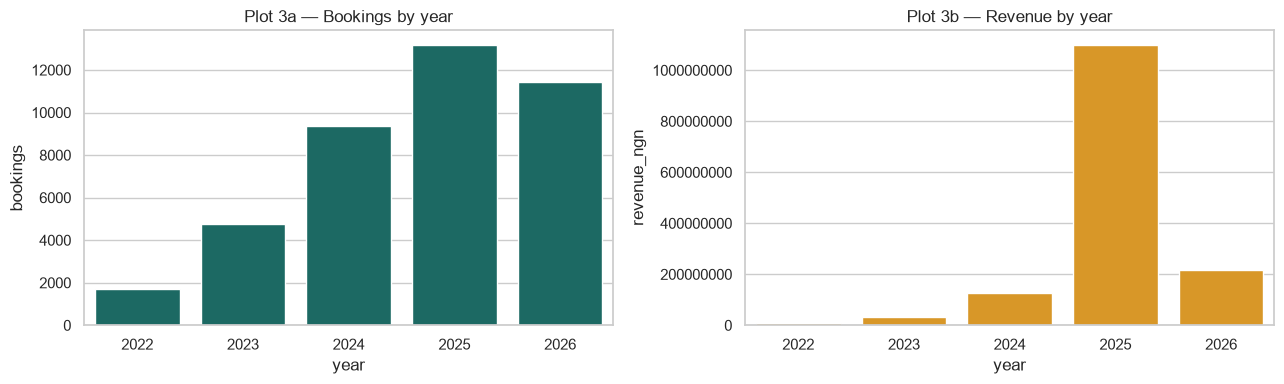

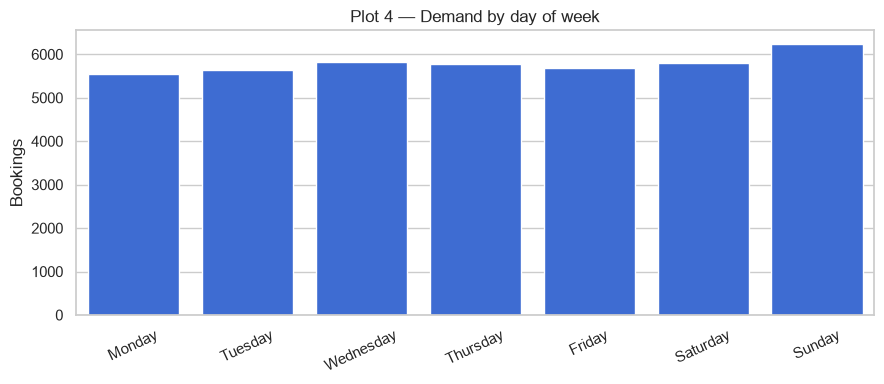

In [ ]:
# 14. Plots 1-4
monthly=bookings.assign(month_dt=bookings.booking_date.dt.to_period("M").dt.to_timestamp()).groupby("month_dt").agg(bookings=("booking_id","nunique"),completed=("completed_flag","sum")).reset_index(); monthly["rolling_3m"]=monthly.bookings.rolling(3,min_periods=1).mean()
fig,ax=plt.subplots(figsize=(14,4)); ax.plot(monthly.month_dt,monthly.bookings,color=PALETTE,alpha=.4,label="Monthly bookings"); ax.plot(monthly.month_dt,monthly.rolling_3m,color=PALETTE,lw=3,label="3-month rolling average"); ax.set(title="Plot 1 — Monthly booking volume",ylabel="Bookings"); ax.legend(); plt.tight_layout(); plt.show()
rev=bookings.assign(month_dt=bookings.booking_date.dt.to_period("M").dt.to_timestamp()).groupby("month_dt",as_index=False).amount_paid_ngn.sum(); fig,ax=plt.subplots(figsize=(14,4)); ax.plot(rev.month_dt,rev.amount_paid_ngn,color=ACCENT,lw=2); ax.fill_between(rev.month_dt,rev.amount_paid_ngn,color=ACCENT,alpha=.15); ax.set(title="Plot 2 — Parsed paid revenue over time",ylabel="NGN"); ax.ticklabel_format(axis="y",style="plain"); plt.tight_layout(); plt.show()
yearly=bookings.groupby("year",as_index=False).agg(bookings=("booking_id","nunique"),revenue_ngn=("amount_paid_ngn","sum")); fig,ax=plt.subplots(1,2,figsize=(13,4)); sns.barplot(data=yearly,x="year",y="bookings",color=PALETTE,ax=ax[0]); sns.barplot(data=yearly,x="year",y="revenue_ngn",color=ACCENT,ax=ax[1]); ax[0].set(title="Plot 3a — Bookings by year"); ax[1].set(title="Plot 3b — Revenue by year"); ax[1].ticklabel_format(axis="y",style="plain"); plt.tight_layout(); plt.show()
dow_order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]; dow=bookings.day_of_week.value_counts().reindex(dow_order).fillna(0); fig,ax=plt.subplots(figsize=(9,4)); sns.barplot(x=dow.index,y=dow.values,color=BLUE,ax=ax); ax.set(title="Plot 4 — Demand by day of week",xlabel="",ylabel="Bookings"); ax.tick_params(axis="x",rotation=25); plt.tight_layout(); plt.show()

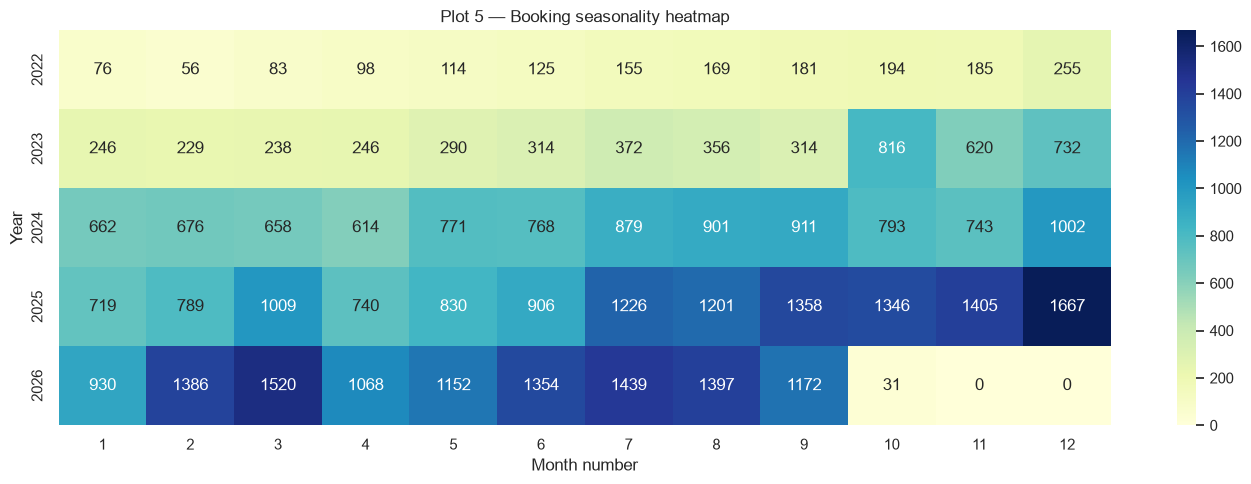

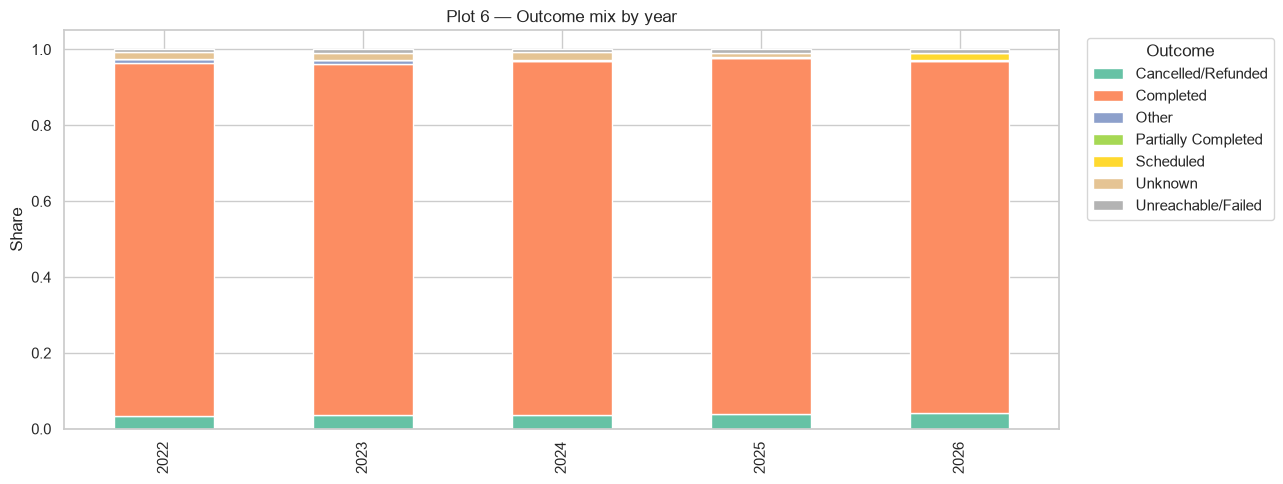

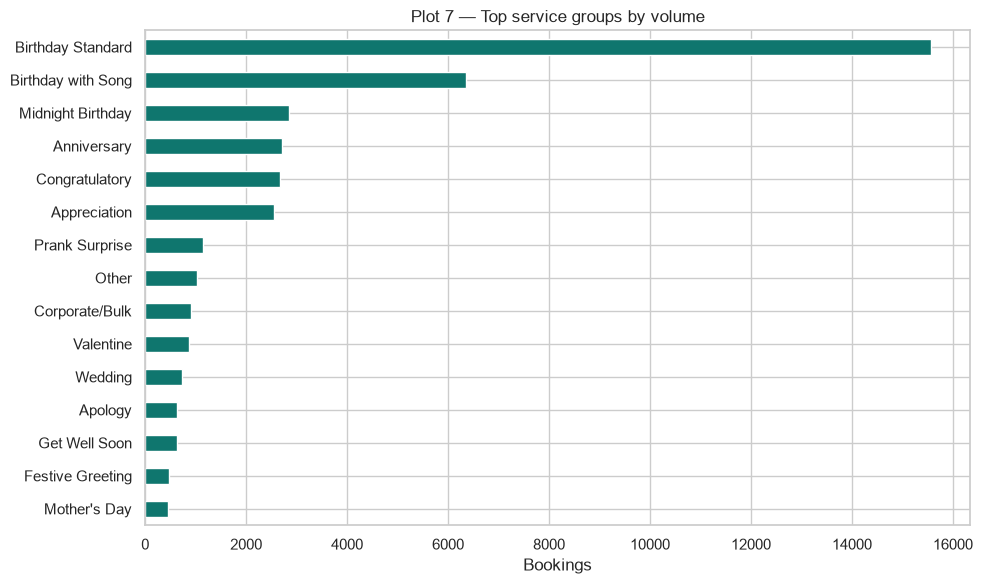

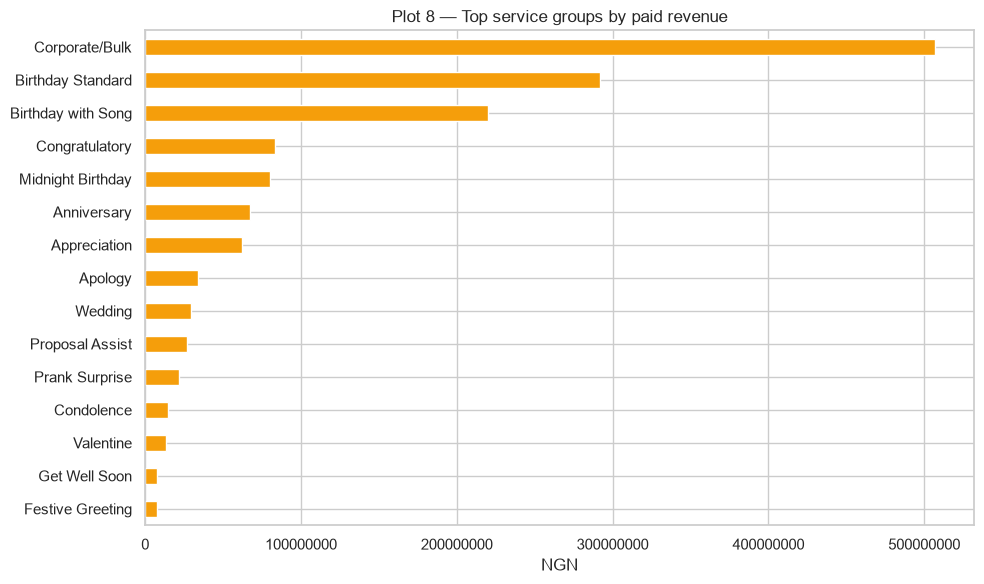

In [ ]:
# 15. Plots 5-8
heat=bookings.pivot_table(index="year",columns="month_num",values="booking_id",aggfunc="nunique",fill_value=0).reindex(columns=range(1,13),fill_value=0); fig,ax=plt.subplots(figsize=(14,5)); sns.heatmap(heat,annot=True,fmt=".0f",cmap="YlGnBu",ax=ax); ax.set(title="Plot 5 — Booking seasonality heatmap",xlabel="Month number",ylabel="Year"); plt.tight_layout(); plt.show()
sy=pd.crosstab(bookings.year,bookings.status,normalize="index"); fig,ax=plt.subplots(figsize=(13,5)); sy.plot(kind="bar",stacked=True,colormap="Set2",ax=ax); ax.set(title="Plot 6 — Outcome mix by year",ylabel="Share",xlabel=""); ax.legend(title="Outcome",bbox_to_anchor=(1.02,1),loc="upper left"); plt.tight_layout(); plt.show()
sc=bookings.service_group.value_counts().head(15).sort_values(); fig,ax=plt.subplots(figsize=(10,6)); sc.plot(kind="barh",color=PALETTE,ax=ax); ax.set(title="Plot 7 — Top service groups by volume",xlabel="Bookings",ylabel=""); plt.tight_layout(); plt.show()
sr=bookings.groupby("service_group").amount_paid_ngn.sum().sort_values().tail(15); fig,ax=plt.subplots(figsize=(10,6)); sr.plot(kind="barh",color=ACCENT,ax=ax); ax.set(title="Plot 8 — Top service groups by paid revenue",xlabel="NGN",ylabel=""); ax.ticklabel_format(axis="x",style="plain"); plt.tight_layout(); plt.show()

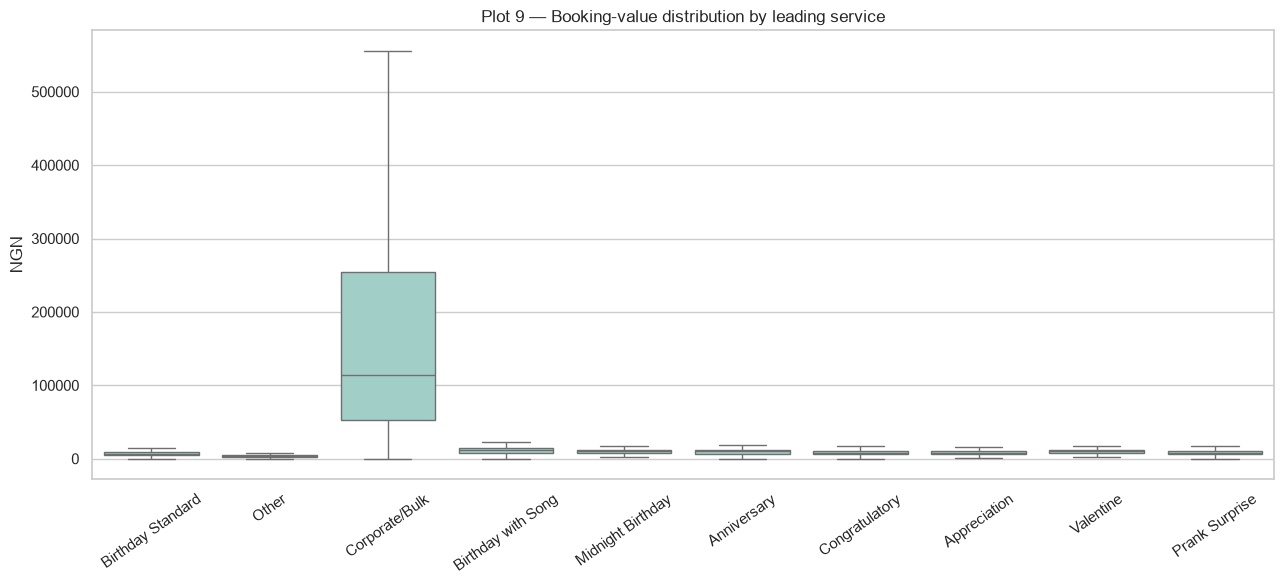

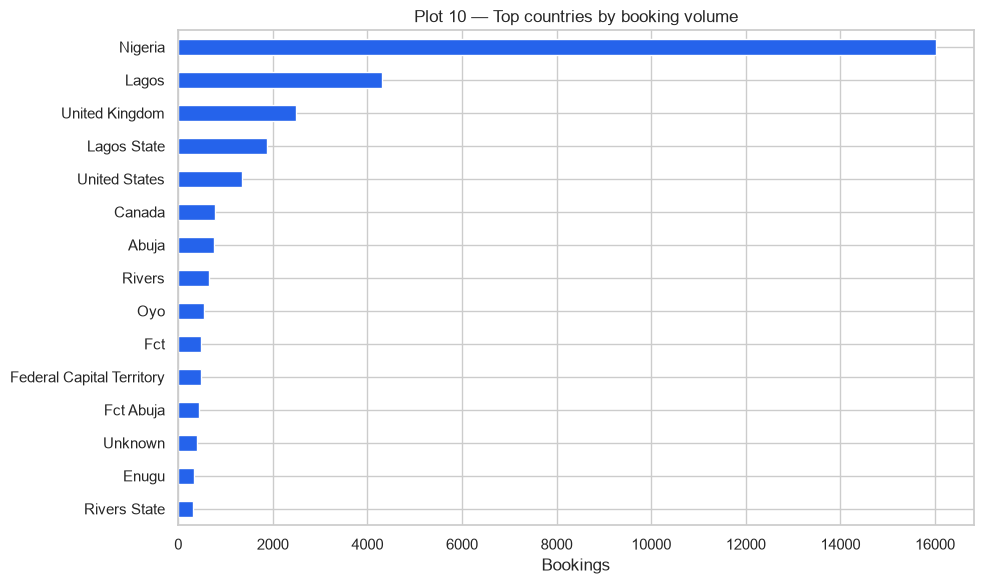

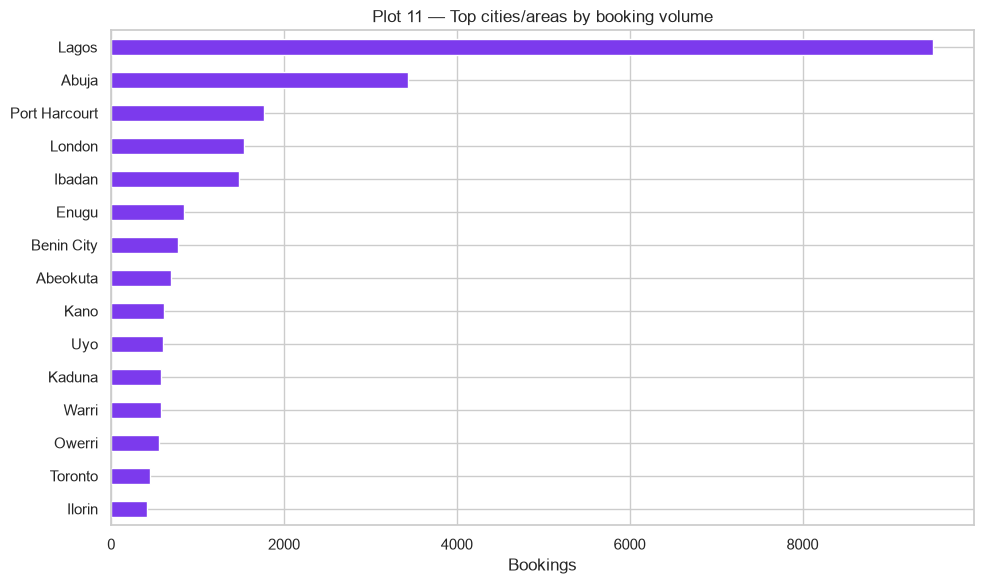

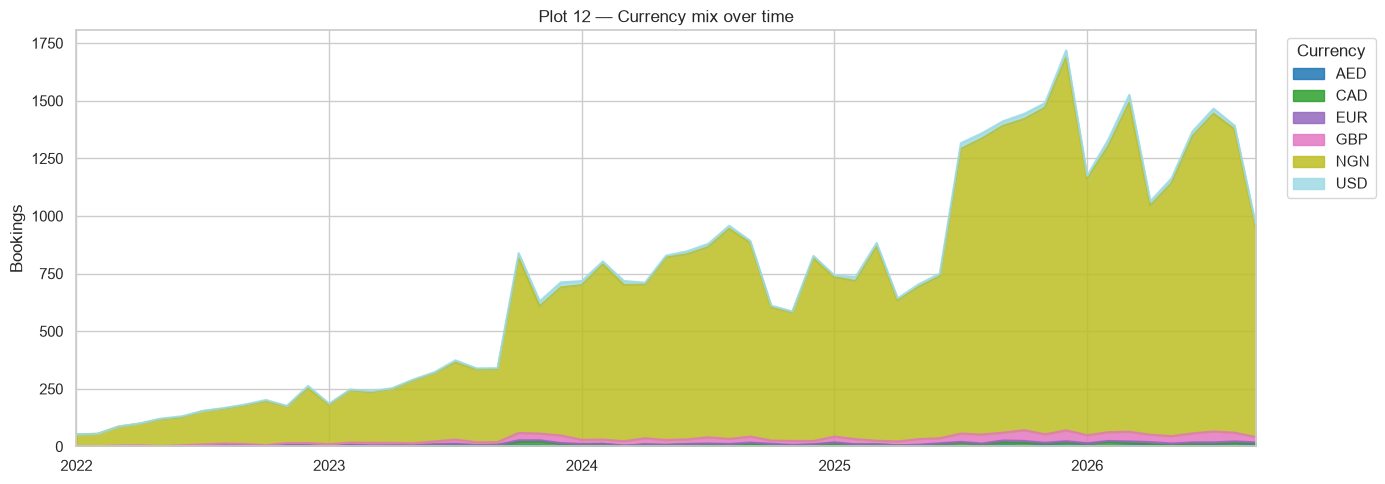

In [ ]:
# 16. Plots 9-12
top=bookings.service_group.value_counts().head(10).index; fig,ax=plt.subplots(figsize=(13,6)); sns.boxplot(data=bookings[bookings.service_group.isin(top)&bookings.amount_paid_ngn.notna()],x="service_group",y="amount_paid_ngn",showfliers=False,color="#99D5CC",ax=ax); ax.set(title="Plot 9 — Booking-value distribution by leading service",xlabel="",ylabel="NGN"); ax.tick_params(axis="x",rotation=35); plt.tight_layout(); plt.show()
country=bookings.country_std.value_counts().head(15).sort_values(); fig,ax=plt.subplots(figsize=(10,6)); country.plot(kind="barh",color=BLUE,ax=ax); ax.set(title="Plot 10 — Top countries by booking volume",xlabel="Bookings",ylabel=""); plt.tight_layout(); plt.show()
city=bookings.city_std.value_counts().head(15).sort_values(); fig,ax=plt.subplots(figsize=(10,6)); city.plot(kind="barh",color=PURPLE,ax=ax); ax.set(title="Plot 11 — Top cities/areas by booking volume",xlabel="Bookings",ylabel=""); plt.tight_layout(); plt.show()
cm=pd.crosstab(bookings.booking_month,bookings.currency).sort_index(); fig,ax=plt.subplots(figsize=(14,5)); cm.plot.area(stacked=True,alpha=.85,ax=ax,colormap="tab20"); ax.set(title="Plot 12 — Currency mix over time",ylabel="Bookings",xlabel=""); ax.legend(title="Currency",bbox_to_anchor=(1.02,1),loc="upper left"); plt.tight_layout(); plt.show()

## 9. Customer behaviour, retention and repeat booking (Plots 13–20)

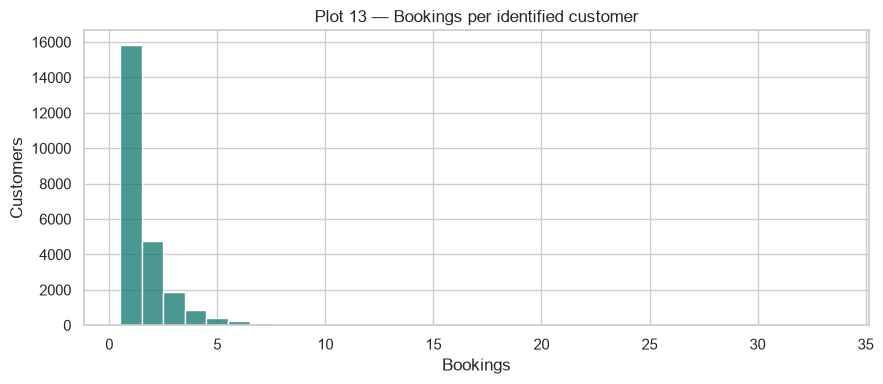

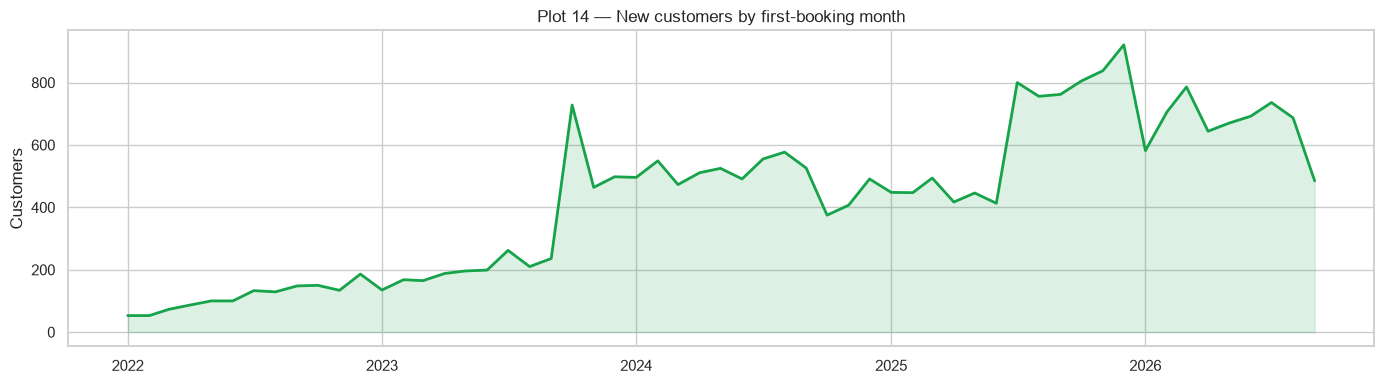

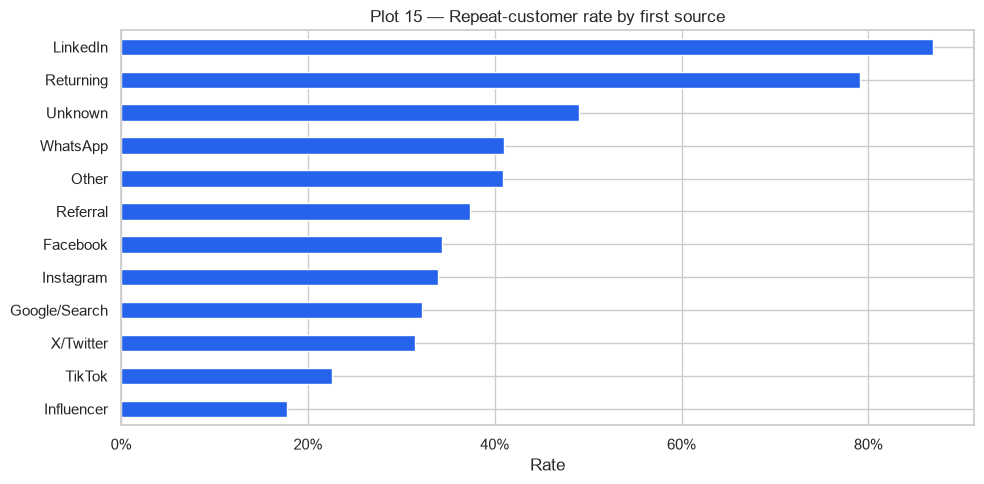

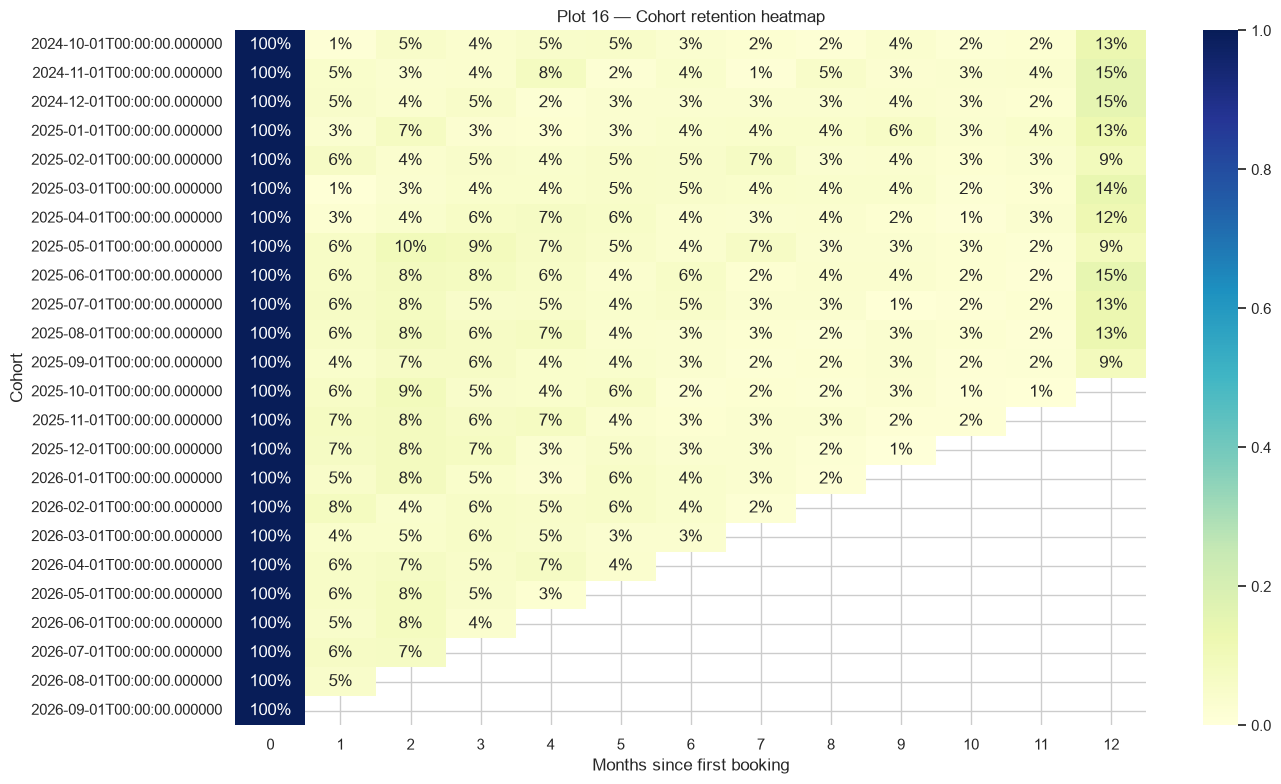

In [ ]:
# 17. Plots 13-16
fig,ax=plt.subplots(figsize=(9,4)); sns.histplot(customer_level.bookings,discrete=True,color=PALETTE,ax=ax); ax.set(title="Plot 13 — Bookings per identified customer",xlabel="Bookings",ylabel="Customers"); plt.tight_layout(); plt.show()
cs=customer_level.groupby("cohort_month").size().reset_index(name="new_customers"); fig,ax=plt.subplots(figsize=(14,4)); ax.plot(cs.cohort_month,cs.new_customers,color=GREEN,lw=2); ax.fill_between(cs.cohort_month,cs.new_customers,color=GREEN,alpha=.15); ax.set(title="Plot 14 — New customers by first-booking month",ylabel="Customers"); plt.tight_layout(); plt.show()
rs=customer_level.groupby("first_source").agg(customers=("customer_id","nunique"),repeat_rate=("is_repeat_customer","mean")).query("customers>=20").sort_values("repeat_rate"); fig,ax=plt.subplots(figsize=(10,5)); rs.repeat_rate.plot.barh(color=BLUE,ax=ax); ax.set(title="Plot 15 — Repeat-customer rate by first source",xlabel="Rate",ylabel=""); ax.xaxis.set_major_formatter(lambda x,pos:f"{x:.0%}"); plt.tight_layout(); plt.show()
a=bookings.dropna(subset=["customer_id"]).copy(); a["cohort_month"]=a.groupby("customer_id").booking_date.transform("min").dt.to_period("M").dt.to_timestamp(); a["activity_month"]=a.booking_date.dt.to_period("M").dt.to_timestamp(); a["period_number"]=(a.activity_month.dt.year-a.cohort_month.dt.year)*12+a.activity_month.dt.month-a.cohort_month.dt.month; cr=a.drop_duplicates(["customer_id","cohort_month","period_number"]).groupby(["cohort_month","period_number"]).customer_id.nunique().reset_index(); base=cr[cr.period_number.eq(0)][["cohort_month","customer_id"]].rename(columns={"customer_id":"base"}); cr=cr.merge(base,on="cohort_month"); cr["retention"]=cr.customer_id/cr.base; rp=cr.pivot(index="cohort_month",columns="period_number",values="retention").iloc[-24:,:13]; fig,ax=plt.subplots(figsize=(14,8)); sns.heatmap(rp,annot=True,fmt=".0%",cmap="YlGnBu",vmin=0,vmax=1,ax=ax); ax.set(title="Plot 16 — Cohort retention heatmap",xlabel="Months since first booking",ylabel="Cohort"); plt.tight_layout(); plt.show()

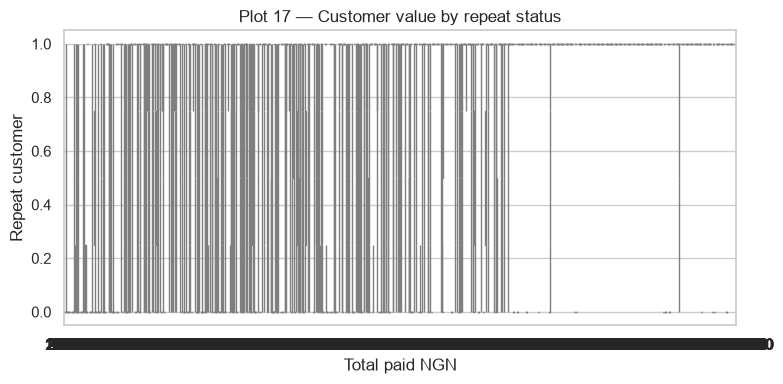

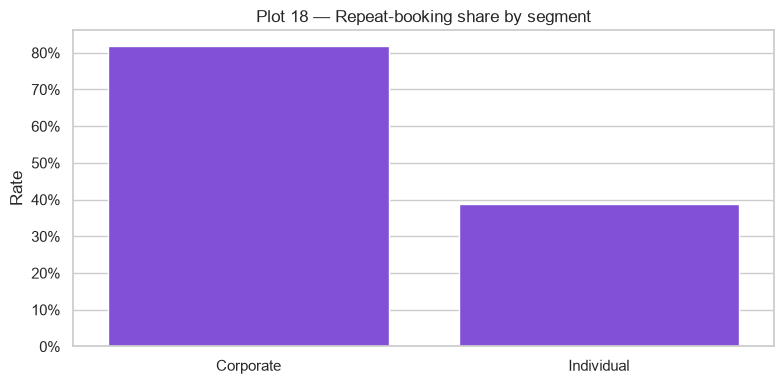

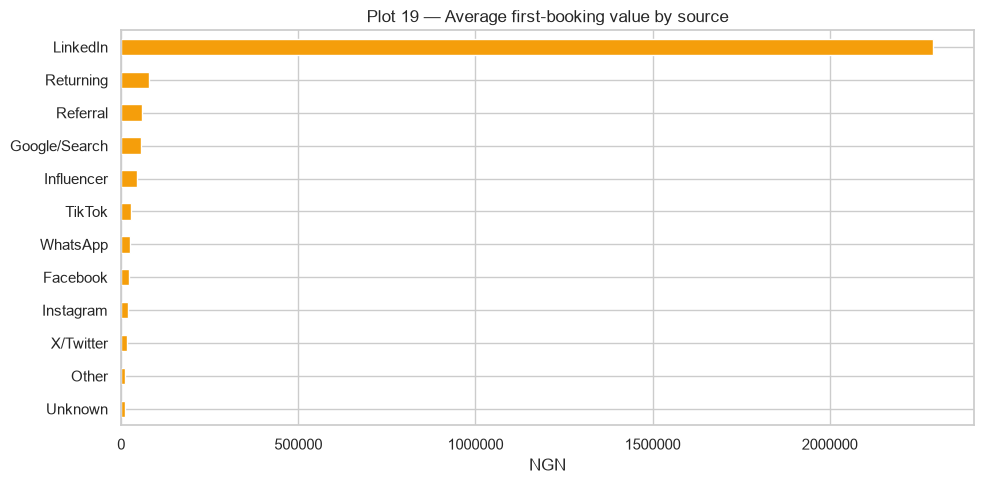

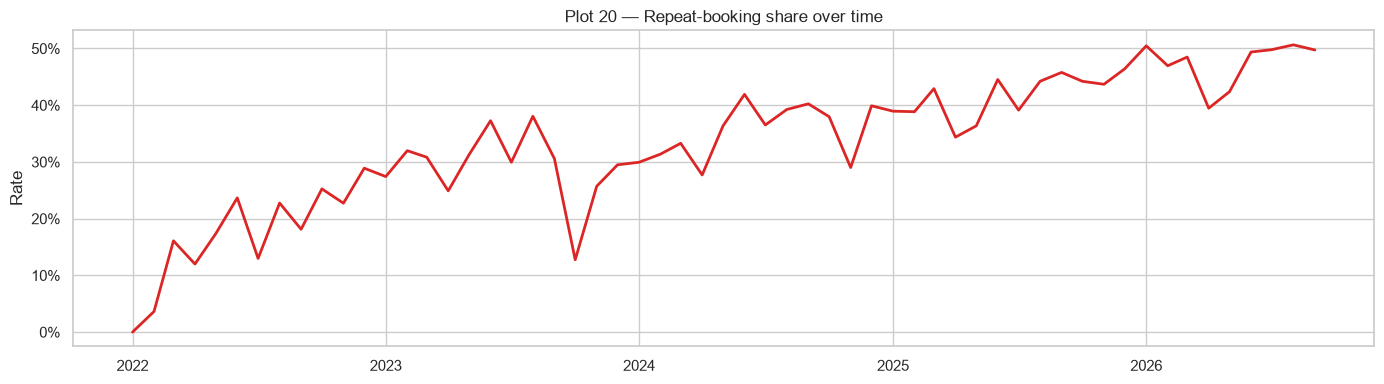

In [ ]:
# 18. Plots 17-20
fig,ax=plt.subplots(figsize=(8,4)); sns.boxplot(data=customer_level,y="is_repeat_customer",x="total_paid_ngn",showfliers=False,color="#B9D7F0",ax=ax); ax.set(title="Plot 17 — Customer value by repeat status",xlabel="Total paid NGN",ylabel="Repeat customer"); plt.tight_layout(); plt.show()
seg=bookings.dropna(subset=["customer_id"]).groupby("customer_segment").agg(customers=("customer_id","nunique"),repeat_rate=("is_repeat_booking","mean")).reset_index(); fig,ax=plt.subplots(figsize=(8,4)); sns.barplot(data=seg,x="customer_segment",y="repeat_rate",color=PURPLE,ax=ax); ax.set(title="Plot 18 — Repeat-booking share by segment",ylabel="Rate",xlabel=""); ax.yaxis.set_major_formatter(lambda x,pos:f"{x:.0%}"); plt.tight_layout(); plt.show()
first=bookings.sort_values(["customer_id","booking_date"]).drop_duplicates("customer_id"); sv=first.groupby("acquisition_source").agg(customers=("customer_id","nunique"),avg_value=("amount_paid_ngn","mean")).query("customers>=20").sort_values("avg_value"); fig,ax=plt.subplots(figsize=(10,5)); sv.avg_value.plot.barh(color=ACCENT,ax=ax); ax.set(title="Plot 19 — Average first-booking value by source",xlabel="NGN",ylabel=""); ax.ticklabel_format(axis="x",style="plain"); plt.tight_layout(); plt.show()
rm=bookings.assign(month_dt=bookings.booking_date.dt.to_period("M").dt.to_timestamp()).groupby("month_dt").agg(bookings=("booking_id","size"),repeat_share=("is_repeat_booking","mean")).reset_index(); fig,ax=plt.subplots(figsize=(14,4)); ax.plot(rm.month_dt,rm.repeat_share,color=RED,lw=2); ax.set(title="Plot 20 — Repeat-booking share over time",ylabel="Rate",xlabel=""); ax.yaxis.set_major_formatter(lambda x,pos:f"{x:.0%}"); plt.tight_layout(); plt.show()

## 10. Operations, payments and customer experience (Plots 21–28)

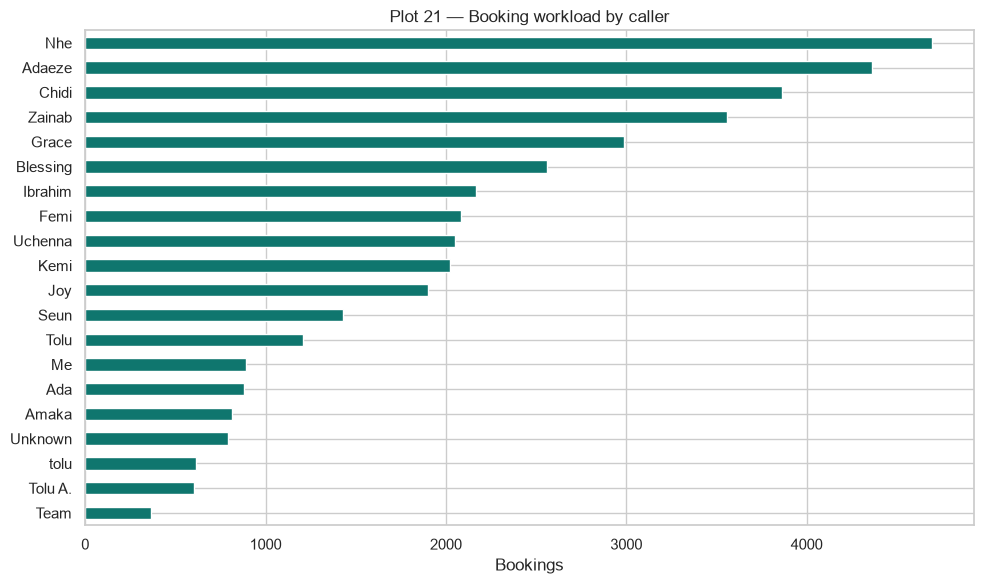

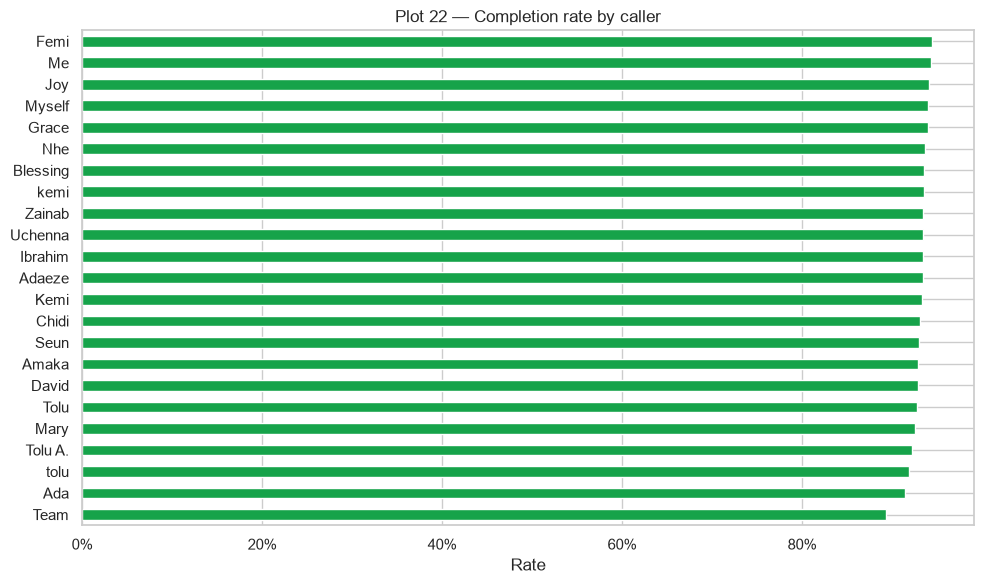

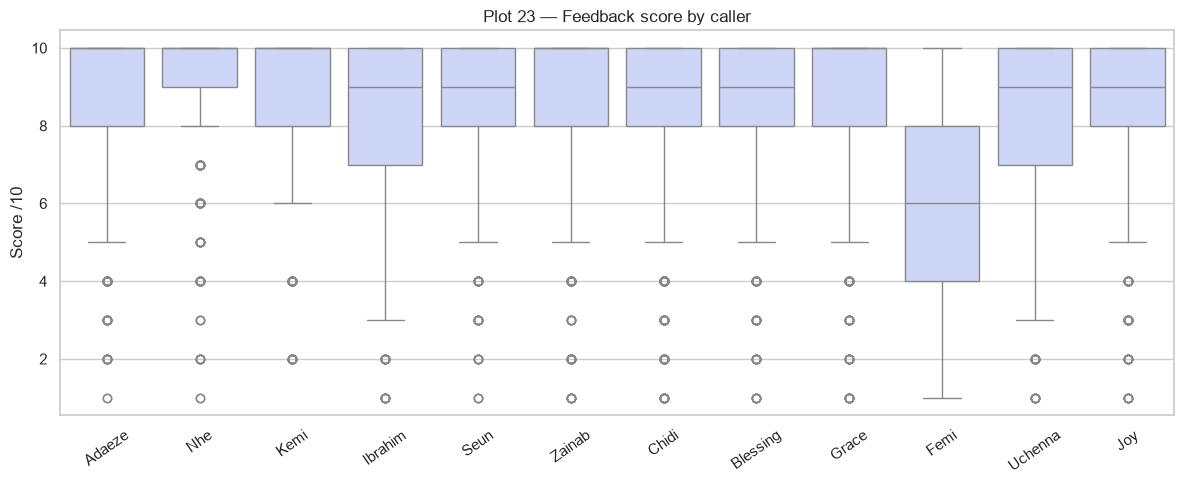

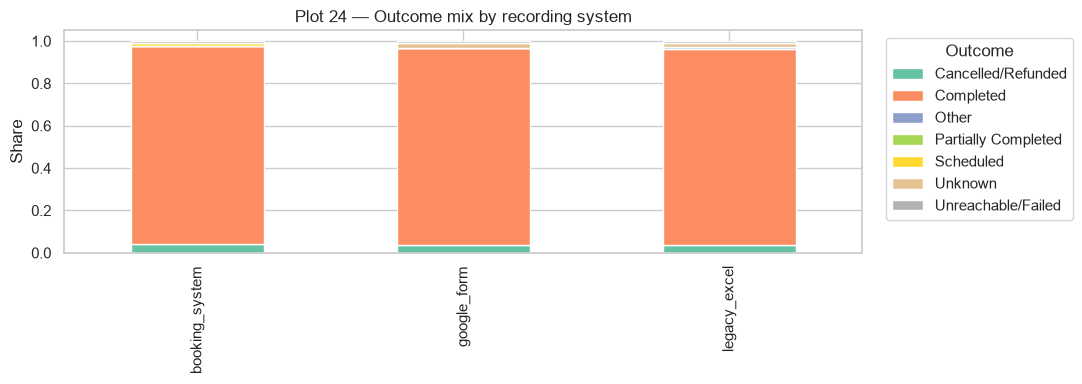

In [ ]:
# 19. Plots 21-24
cc=bookings.caller_name.fillna("Unknown").value_counts().head(20).sort_values(); fig,ax=plt.subplots(figsize=(10,6)); cc.plot.barh(color=PALETTE,ax=ax); ax.set(title="Plot 21 — Booking workload by caller",xlabel="Bookings",ylabel=""); plt.tight_layout(); plt.show()
cp=bookings.groupby("caller_name").agg(bookings=("booking_id","size"),completion_rate=("completed_flag","mean")).query("bookings>=100").sort_values("completion_rate"); fig,ax=plt.subplots(figsize=(10,6)); cp.completion_rate.plot.barh(color=GREEN,ax=ax); ax.set(title="Plot 22 — Completion rate by caller",xlabel="Rate",ylabel=""); ax.xaxis.set_major_formatter(lambda x,pos:f"{x:.0%}"); plt.tight_layout(); plt.show()
cf=bookings.dropna(subset=["rating_10","caller_name"]); keep=cf.caller_name.value_counts().head(12).index; fig,ax=plt.subplots(figsize=(12,5)); sns.boxplot(data=cf[cf.caller_name.isin(keep)],x="caller_name",y="rating_10",color="#C7D2FE",ax=ax); ax.set(title="Plot 23 — Feedback score by caller",xlabel="",ylabel="Score /10"); ax.tick_params(axis="x",rotation=35); plt.tight_layout(); plt.show()
st=pd.crosstab(bookings.source_system,bookings.status,normalize="index"); fig,ax=plt.subplots(figsize=(11,4)); st.plot.bar(stacked=True,colormap="Set2",ax=ax); ax.set(title="Plot 24 — Outcome mix by recording system",ylabel="Share",xlabel=""); ax.legend(title="Outcome",bbox_to_anchor=(1.02,1),loc="upper left"); plt.tight_layout(); plt.show()

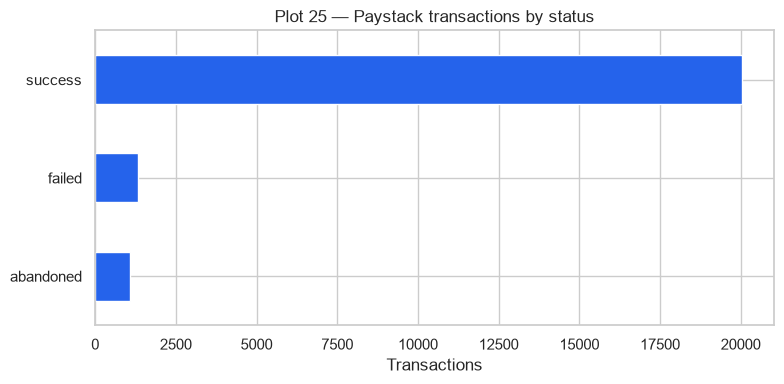

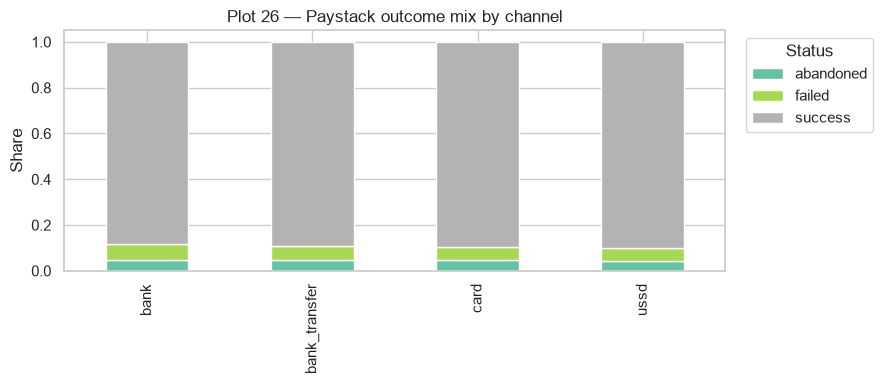

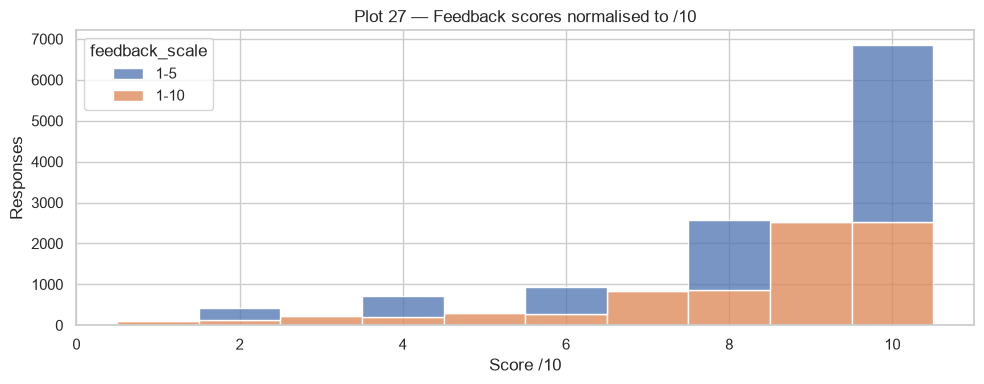

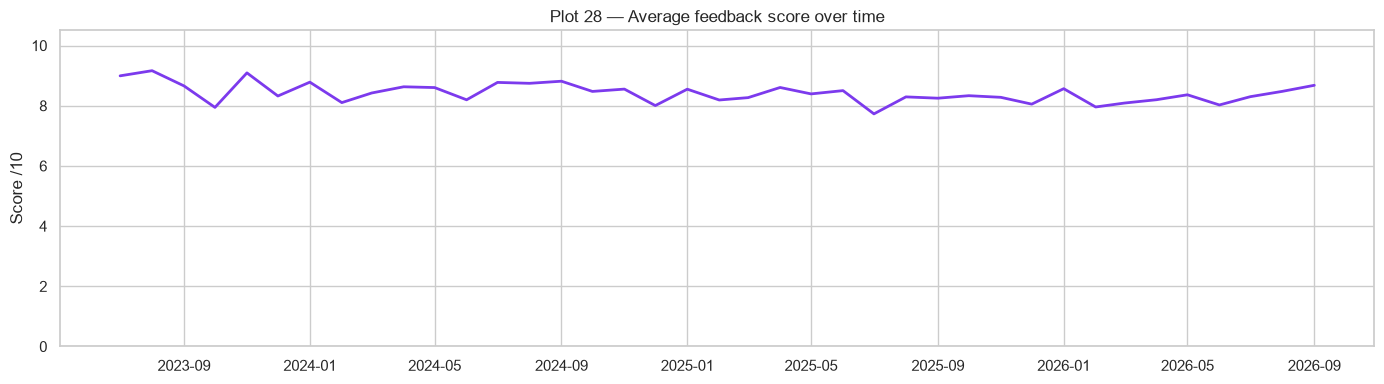

In [ ]:
# 20. Plots 25-28
ps=paystack.status.value_counts().sort_values(); fig,ax=plt.subplots(figsize=(8,4)); ps.plot.barh(color=BLUE,ax=ax); ax.set(title="Plot 25 — Paystack transactions by status",xlabel="Transactions",ylabel=""); plt.tight_layout(); plt.show()
pc=pd.crosstab(paystack.channel,paystack.status,normalize="index"); fig,ax=plt.subplots(figsize=(9,4)); pc.plot.bar(stacked=True,colormap="Set2",ax=ax); ax.set(title="Plot 26 — Paystack outcome mix by channel",ylabel="Share",xlabel=""); ax.legend(title="Status",bbox_to_anchor=(1.02,1),loc="upper left"); plt.tight_layout(); plt.show()
fig,ax=plt.subplots(figsize=(10,4)); sns.histplot(data=feedback.dropna(subset=["overall_10"]),x="overall_10",hue="feedback_scale",multiple="stack",bins=10,discrete=True,ax=ax); ax.set(title="Plot 27 — Feedback scores normalised to /10",xlabel="Score /10",ylabel="Responses"); plt.tight_layout(); plt.show()
fbm=feedback.dropna(subset=["submitted_dt","overall_10"]).assign(month_dt=lambda d:d.submitted_dt.dt.to_period("M").dt.to_timestamp()).groupby("month_dt",as_index=False).agg(avg_score=("overall_10","mean"),responses=("response_id","nunique")); fig,ax=plt.subplots(figsize=(14,4)); ax.plot(fbm.month_dt,fbm.avg_score,color=PURPLE,lw=2); ax.set(title="Plot 28 — Average feedback score over time",ylabel="Score /10",xlabel=""); ax.set_ylim(0,10.5); plt.tight_layout(); plt.show()

## 11. Complaints, enquiries, social media and marketing (Plots 29–39)

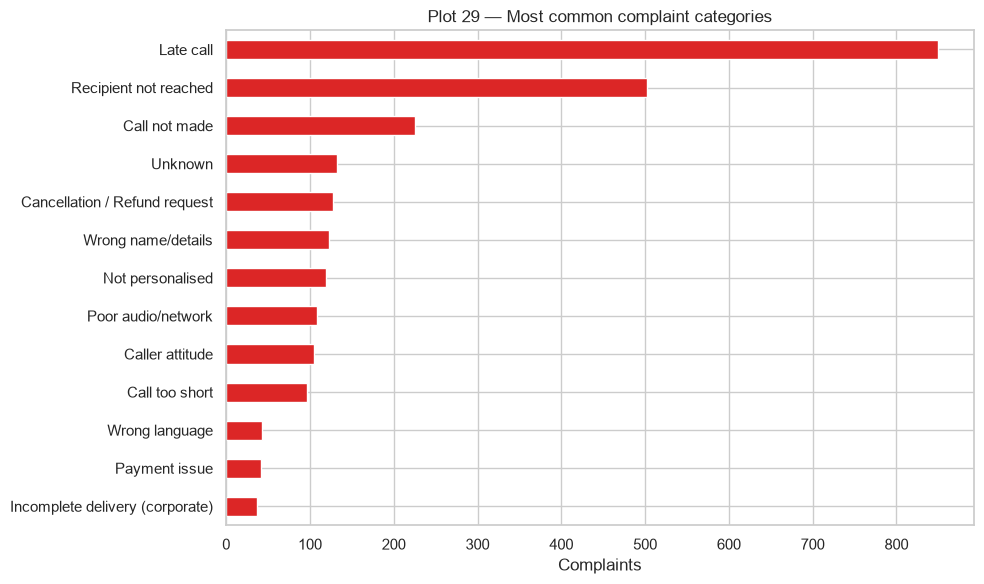

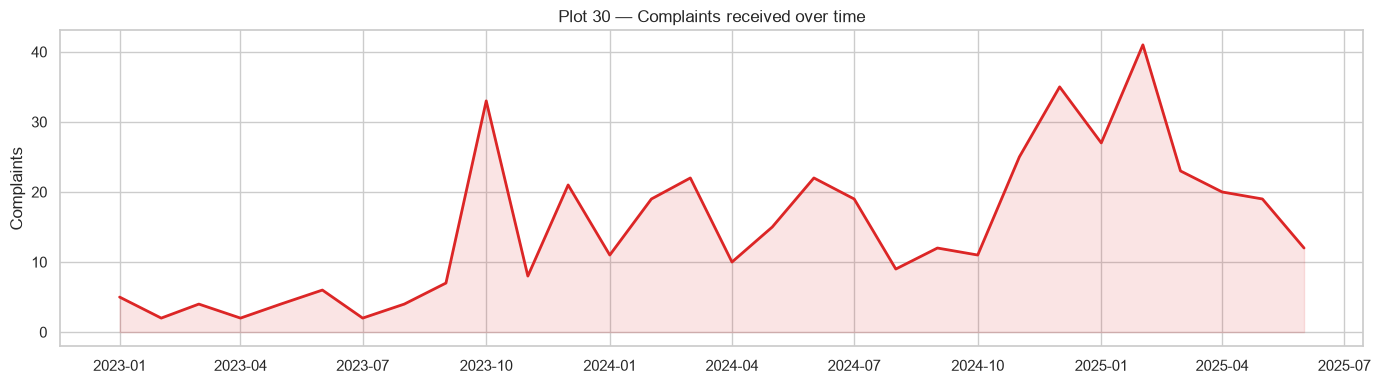

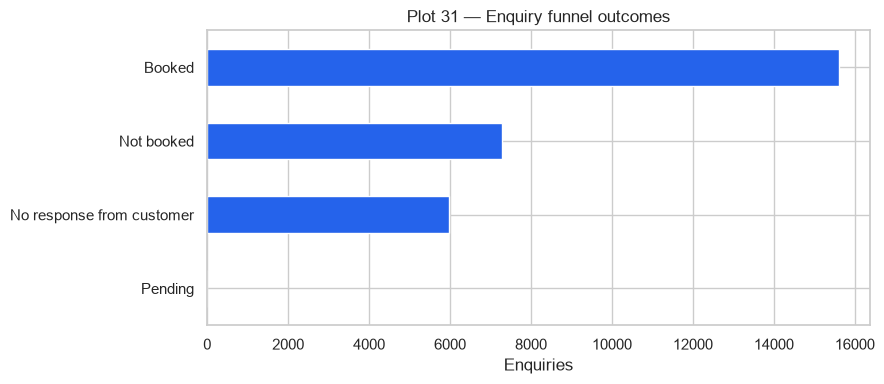

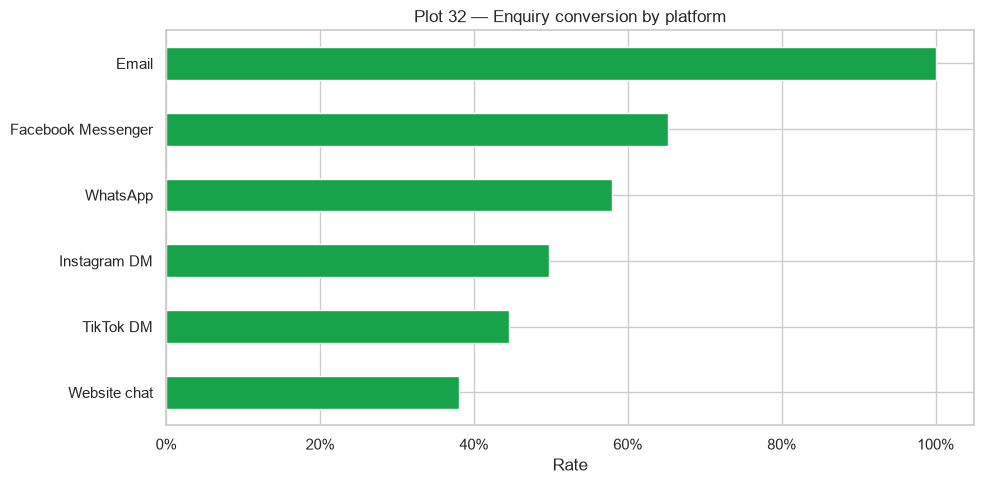

In [ ]:
# 21. Plots 29-32
cat=complaints.Category.fillna("Unknown").value_counts().head(15).sort_values(); fig,ax=plt.subplots(figsize=(10,6)); cat.plot.barh(color=RED,ax=ax); ax.set(title="Plot 29 — Most common complaint categories",xlabel="Complaints",ylabel=""); plt.tight_layout(); plt.show()
cm=complaints.dropna(subset=["date_received"]).assign(month_dt=lambda d:d.date_received.dt.to_period("M").dt.to_timestamp()).groupby("month_dt").size().reset_index(name="complaints"); fig,ax=plt.subplots(figsize=(14,4)); ax.plot(cm.month_dt,cm.complaints,color=RED,lw=2); ax.fill_between(cm.month_dt,cm.complaints,color=RED,alpha=.12); ax.set(title="Plot 30 — Complaints received over time",ylabel="Complaints",xlabel=""); plt.tight_layout(); plt.show()
funnel=enquiries.outcome.value_counts().reindex(["Booked","Not booked","No response from customer","Pending"]).fillna(0).sort_values(); fig,ax=plt.subplots(figsize=(9,4)); funnel.plot.barh(color=BLUE,ax=ax); ax.set(title="Plot 31 — Enquiry funnel outcomes",xlabel="Enquiries",ylabel=""); plt.tight_layout(); plt.show()
pcv=enquiries.groupby("first_contact_platform").agg(enquiries=("enquiry_id","size"),conversion=("outcome",lambda s:(s=="Booked").mean())).query("enquiries>=30").sort_values("conversion"); fig,ax=plt.subplots(figsize=(10,5)); pcv.conversion.plot.barh(color=GREEN,ax=ax); ax.set(title="Plot 32 — Enquiry conversion by platform",xlabel="Rate",ylabel=""); ax.xaxis.set_major_formatter(lambda x,pos:f"{x:.0%}"); plt.tight_layout(); plt.show()

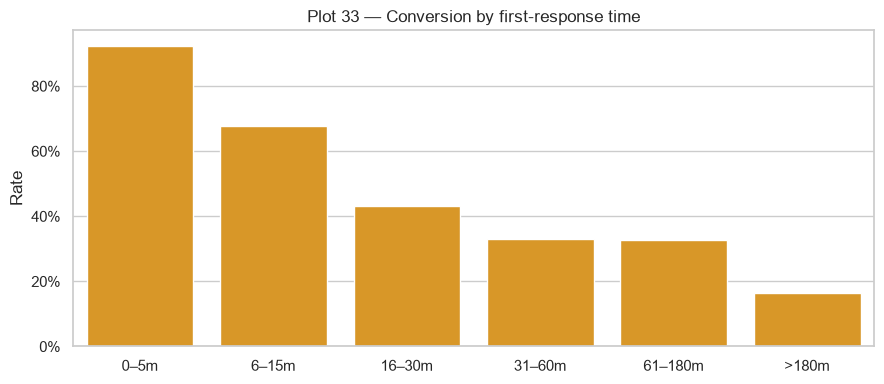

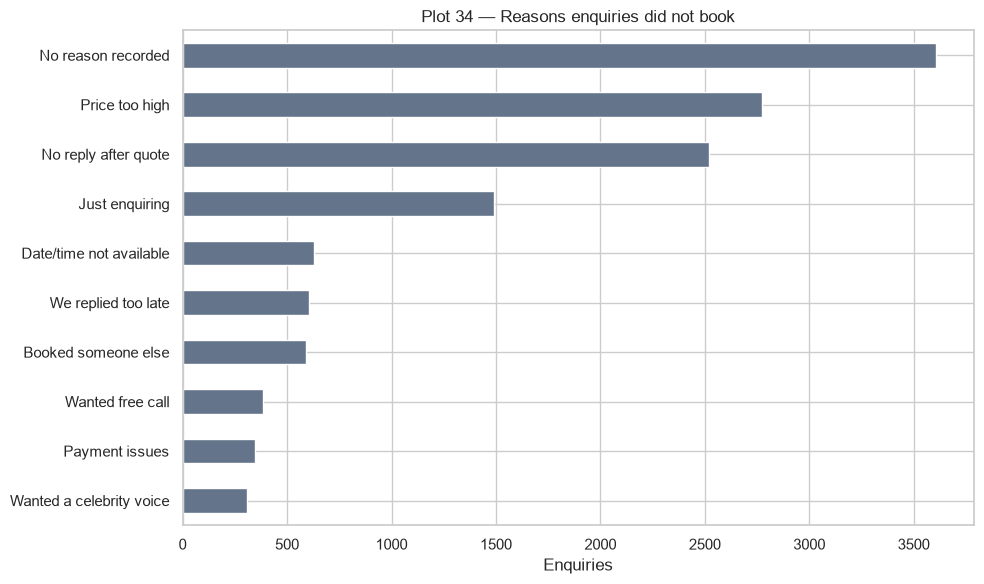

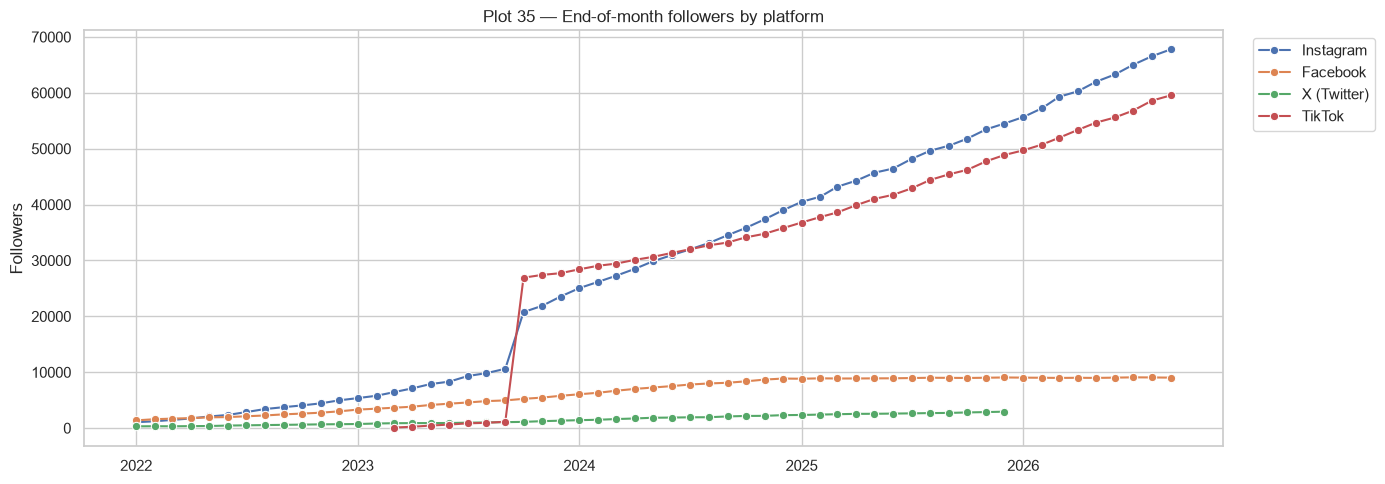

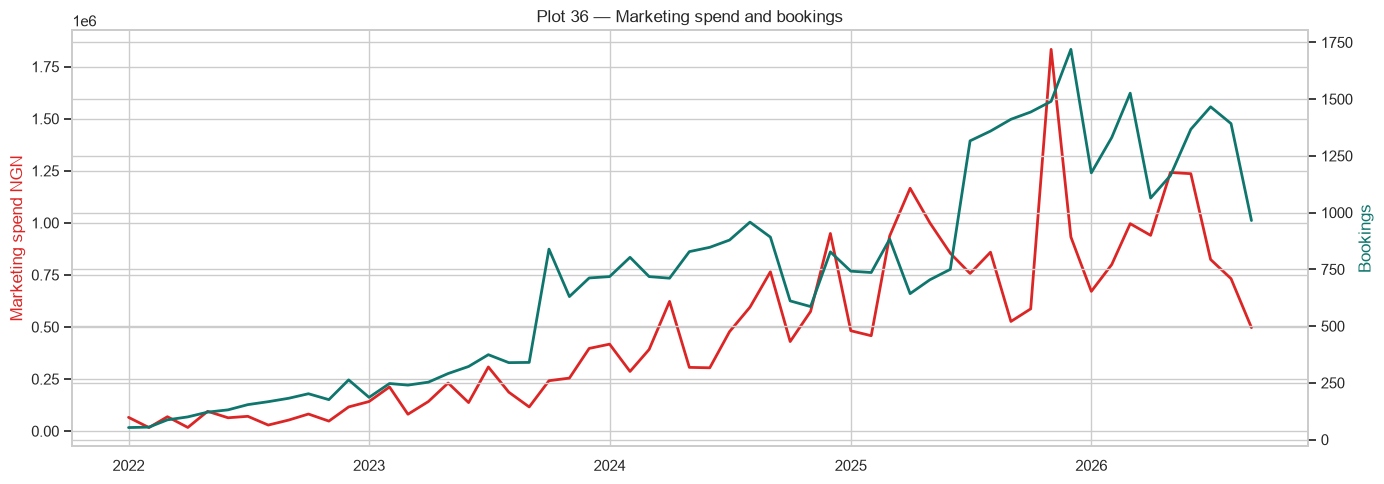

In [ ]:
# 22. Plots 33-36
ep=enquiries.dropna(subset=["first_response_mins"]).copy(); ep["response_band"]=pd.cut(ep.first_response_mins,[-1,5,15,30,60,180,10000],labels=["0–5m","6–15m","16–30m","31–60m","61–180m",">180m"]); sb=ep.groupby("response_band",observed=False).agg(enquiries=("enquiry_id","size"),conversion=("outcome",lambda s:(s=="Booked").mean())).reset_index(); fig,ax=plt.subplots(figsize=(9,4)); sns.barplot(data=sb,x="response_band",y="conversion",color=ACCENT,ax=ax); ax.set(title="Plot 33 — Conversion by first-response time",xlabel="",ylabel="Rate"); ax.yaxis.set_major_formatter(lambda x,pos:f"{x:.0%}"); plt.tight_layout(); plt.show()
reason=enquiries.loc[enquiries.outcome.isin(["Not booked","No response from customer"]),"reason_not_booked"].fillna("No reason recorded").value_counts().head(15).sort_values(); fig,ax=plt.subplots(figsize=(10,6)); reason.plot.barh(color="#64748B",ax=ax); ax.set(title="Plot 34 — Reasons enquiries did not book",xlabel="Enquiries",ylabel=""); plt.tight_layout(); plt.show()
fig,ax=plt.subplots(figsize=(14,5)); sns.lineplot(data=social.dropna(subset=["followers_end_of_month"]),x="month_dt",y="followers_end_of_month",hue="platform",marker="o",ax=ax); ax.set(title="Plot 35 — End-of-month followers by platform",ylabel="Followers",xlabel=""); ax.legend(bbox_to_anchor=(1.02,1),loc="upper left"); plt.tight_layout(); plt.show()
mk=monthly_kpis; fig,ax1=plt.subplots(figsize=(14,5)); ax1.plot(mk.month_dt,mk.marketing_spend_ngn,color=RED,lw=2); ax1.set_ylabel("Marketing spend NGN",color=RED); ax2=ax1.twinx(); ax2.plot(mk.month_dt,mk.bookings,color=PALETTE,lw=2); ax2.set_ylabel("Bookings",color=PALETTE); ax1.set_title("Plot 36 — Marketing spend and bookings"); plt.tight_layout(); plt.show()

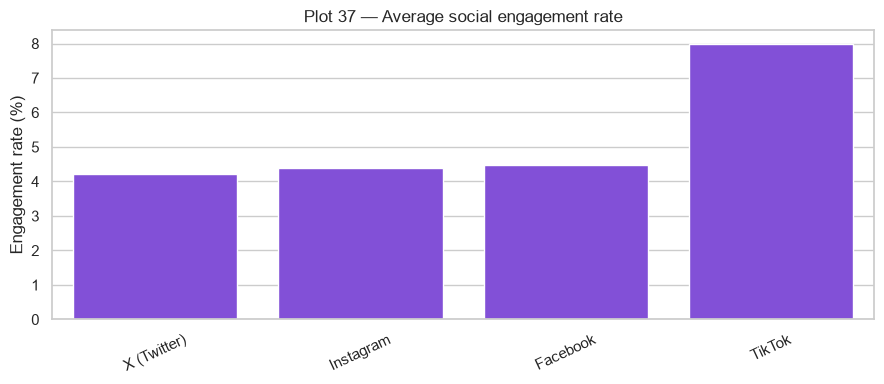

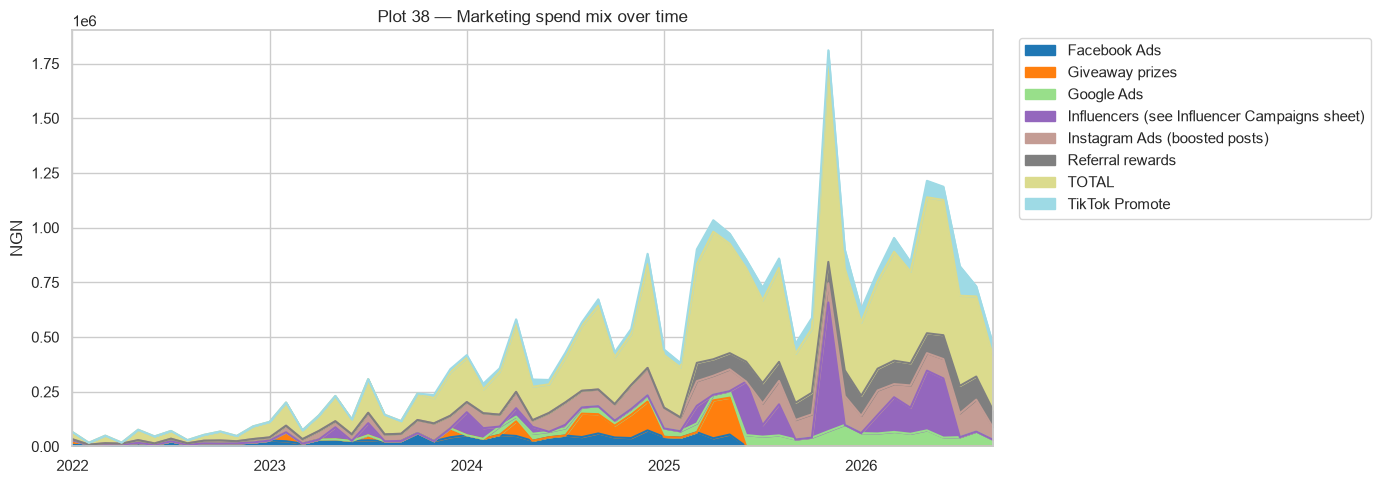

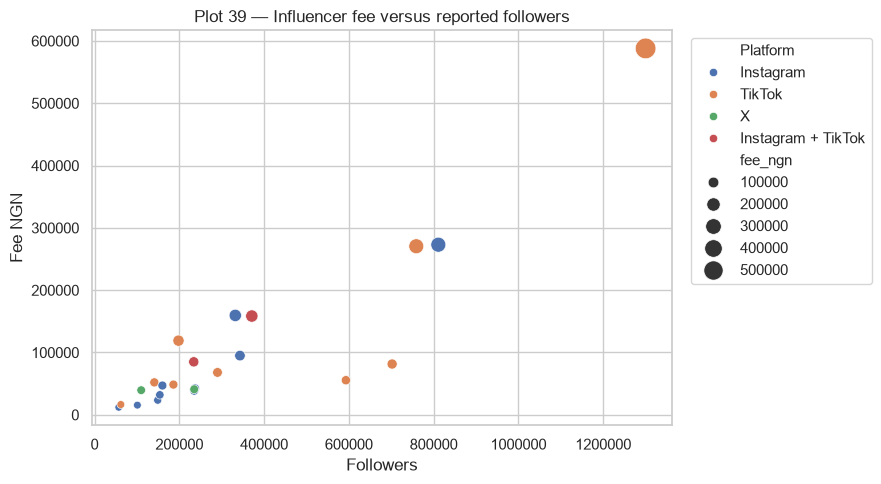

In [ ]:
# 23. Plots 37-39
eng=social.groupby("platform",as_index=False).agg(avg_engagement_pct=("engagement_rate_pct","mean")).sort_values("avg_engagement_pct"); fig,ax=plt.subplots(figsize=(9,4)); sns.barplot(data=eng,x="platform",y="avg_engagement_pct",color=PURPLE,ax=ax); ax.set(title="Plot 37 — Average social engagement rate",xlabel="",ylabel="Engagement rate (%)"); ax.tick_params(axis="x",rotation=25); plt.tight_layout(); plt.show()
items=spend_long.groupby("channel_item").spend_ngn.sum().nlargest(8).index; mix=spend_long[spend_long.channel_item.isin(items)].pivot_table(index="month_dt",columns="channel_item",values="spend_ngn",aggfunc="sum",fill_value=0); fig,ax=plt.subplots(figsize=(14,5)); ((mix.plot.area(stacked=True,ax=ax,colormap="tab20") if len(mix) and mix.select_dtypes(include=np.number).shape[1] else ax.text(0.5,0.5,"No numeric marketing spend available",ha="center",va="center")) if len(mix) and mix.select_dtypes(include=np.number).shape[1] else ax.text(0.5,0.5,"No numeric marketing spend available",ha="center",va="center")); ax.set(title="Plot 38 — Marketing spend mix over time",ylabel="NGN",xlabel=""); ax.legend(bbox_to_anchor=(1.02,1),loc="upper left"); plt.tight_layout(); plt.show()
inf=influencers.dropna(subset=["fee_ngn","followers_num"]); fig,ax=plt.subplots(figsize=(9,5)); sns.scatterplot(data=inf,x="followers_num",y="fee_ngn",hue="Platform",size="fee_ngn",sizes=(30,220),ax=ax); ax.set(title="Plot 39 — Influencer fee versus reported followers",xlabel="Followers",ylabel="Fee NGN"); ax.ticklabel_format(axis="x",style="plain"); ax.legend(bbox_to_anchor=(1.02,1),loc="upper left"); plt.tight_layout(); plt.show()

## 12. Repeat-booking driver model

Rows: 24306 | train: 19445 | test: 4861 | repeat rate: 0.347 | split: temporal 80/20 | test ROC-AUC: 0.6008499335040756
              precision    recall  f1-score   support

           0       0.88      0.62      0.72      4112
           1       0.20      0.52      0.29       749

    accuracy                           0.60      4861
   macro avg       0.54      0.57      0.51      4861
weighted avg       0.77      0.60      0.66      4861



,feature,coefficient,odds_ratio
21,cat__acquisition_source_Influencer,-0.84,0.43
27,cat__acquisition_source_TikTok,-0.56,0.57
32,cat__customer_segment_Individual,-0.41,0.66
20,cat__acquisition_source_Google/Search,-0.32,0.73
30,cat__acquisition_source_X/Twitter,-0.28,0.75
16,cat__service_group_Valentine,-0.26,0.77
34,cat__country_group_Nigeria,-0.21,0.81
17,cat__service_group_Voice Note,-0.19,0.82
19,cat__acquisition_source_Facebook,-0.18,0.83
39,cat__first_month_10,-0.17,0.84


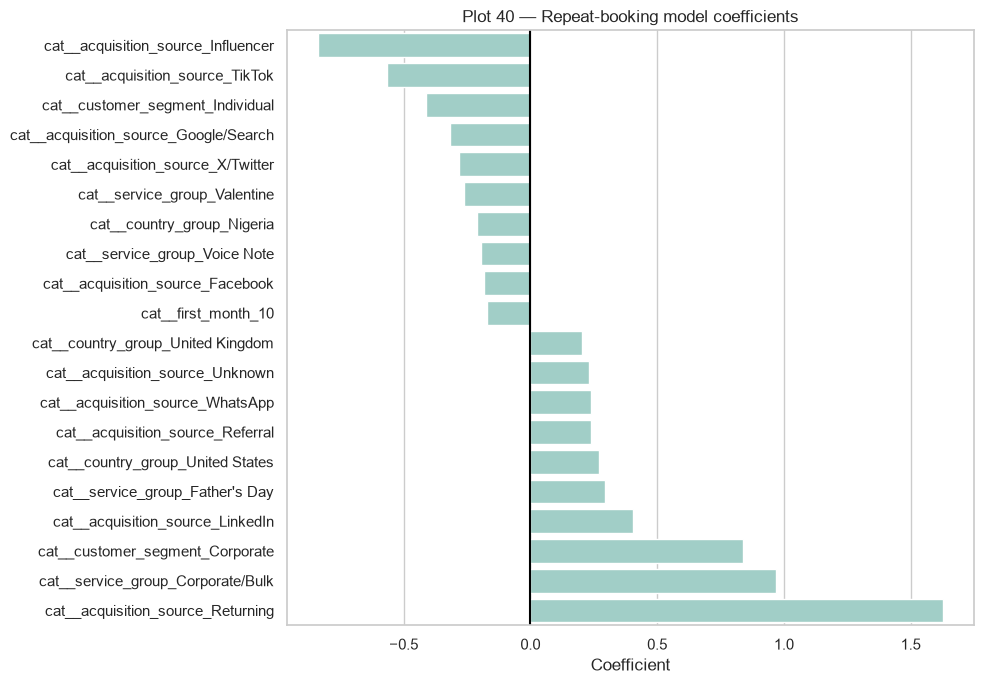

In [ ]:
# 24. Interpretable logistic regression using first-booking features only
model_output=pd.DataFrame()
try:
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import OneHotEncoder,StandardScaler
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score, classification_report
    first=bookings.dropna(subset=["customer_id"]).sort_values(["customer_id","booking_date"]).drop_duplicates("customer_id").copy()
    first["repeat_target"]=first.customer_id.map(customer_level.set_index("customer_id").is_repeat_customer).astype(int)
    first["first_value_log"]=np.log1p(first.amount_paid_ngn.clip(lower=0)); first["first_month"]=first.booking_date.dt.month.astype("string"); first["country_group"]=first.country_std.where(first.country_std.isin(["Nigeria","United Kingdom","United States","Canada"]),"Other/Unknown")
    feats=["service_group","acquisition_source","customer_segment","country_group","first_month","first_value_log"]; cats=feats[:-1]
    cutoff=first.booking_date.quantile(0.8); train=first[first.booking_date.le(cutoff)].copy(); test=first[first.booking_date.gt(cutoff)].copy(); split_label="temporal 80/20"
    if len(test)<20 or train.repeat_target.nunique()<2 or test.repeat_target.nunique()<2:
        from sklearn.model_selection import train_test_split
        train,test=train_test_split(first,test_size=0.2,random_state=42,stratify=first.repeat_target); split_label="stratified fallback because temporal test set lacked both classes"
    pre=ColumnTransformer([("cat",Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("oh",OneHotEncoder(handle_unknown="ignore"))]),cats),("num",Pipeline([("imp",SimpleImputer(strategy="median")),("scale",StandardScaler())]),["first_value_log"])])
    model=Pipeline([("pre",pre),("logit",LogisticRegression(max_iter=1500,class_weight="balanced"))]); model.fit(train[feats],train.repeat_target); pred=model.predict_proba(test[feats])[:,1]
    names=model.named_steps["pre"].get_feature_names_out(); coefs=model.named_steps["logit"].coef_[0]; model_output=pd.DataFrame({"feature":names,"coefficient":coefs,"odds_ratio":np.exp(coefs)}).sort_values("coefficient")
    auc=roc_auc_score(test.repeat_target,pred) if test.repeat_target.nunique()==2 else np.nan
    print("Rows:",len(first),"| train:",len(train),"| test:",len(test),"| repeat rate:",round(first.repeat_target.mean(),3),"| split:",split_label,"| test ROC-AUC:",auc)
    print(classification_report(test.repeat_target,(pred>=0.5).astype(int),zero_division=0)); display(model_output)
    cc=pd.concat([model_output.head(10),model_output.tail(10)]).drop_duplicates().sort_values("coefficient"); fig,ax=plt.subplots(figsize=(10,7)); sns.barplot(data=cc,x="coefficient",y="feature",color="#99D5CC",ax=ax); ax.axvline(0,color="black"); ax.set(title="Plot 40 — Repeat-booking model coefficients",xlabel="Coefficient",ylabel=""); plt.tight_layout(); plt.show()
except Exception as exc:
    print("Model skipped:",repr(exc))

## 13. Data-grounded deductions and management actions

In [ ]:
# 25. Generate refreshed deductions
top_service=bookings.service_group.value_counts().index[0]; top_service_share=bookings.service_group.value_counts(normalize=True).iloc[0]; top_source=bookings.acquisition_source.value_counts().index[0]; peak_month=monthly.loc[monthly.bookings.idxmax(),"month_dt"].strftime("%b %Y"); best_platform=pcv.conversion.idxmax(); best_platform_rate=pcv.conversion.max(); top_complaint=complaints.Category.value_counts().index[0]
deductions=[
f"Demand concentration: {top_service} is the most-booked service group ({top_service_share:.1%} of headline bookings).",
f"Seasonality: {peak_month} is the highest-volume month with {int(monthly.bookings.max()):,} bookings.",
f"Acquisition: {top_source} is the most common recorded source. First-booking source is the appropriate acquisition lens because repeat rows often say returning.",
f"Retention: {customer_level.is_repeat_customer.mean():.1%} of identified customers have more than one booking within the observed window.",
f"Funnel: {best_platform} has the highest enquiry conversion among platforms with at least 30 enquiries ({best_platform_rate:.1%}).",
f"Customer experience: {top_complaint} is the most common complaint category ({int(complaints.Category.value_counts().iloc[0]):,} records).",
"Revenue control: booking-paid amounts include non-Paystack methods, so Paystack should be used as a settlement diagnostic rather than the sole revenue ledger."
]
for i,d in enumerate(deductions,1): print(f"{i}. {d}")
actions=["Plan caller capacity around seasonal peaks and festive periods.","Separate first-acquisition reporting from returning-customer activity.","Set and monitor enquiry response-time service levels by platform.","Use complaint categories to target training and service recovery.","Reconcile booking-paid revenue, Paystack settlements and non-Paystack methods monthly.","Treat model coefficients as hypotheses for experiments, not causal claims."]
print("\nRecommended actions"); [print("-",a) for a in actions]

1. Demand concentration: Birthday Standard is the most-booked service group (38.4% of headline bookings).
2. Seasonality: Dec 2025 is the highest-volume month with 1,719 bookings.
3. Acquisition: Returning is the most common recorded source. First-booking source is the appropriate acquisition lens because repeat rows often say returning.
4. Retention: 34.7% of identified customers have more than one booking within the observed window.
5. Funnel: Email has the highest enquiry conversion among platforms with at least 30 enquiries (100.0%).
6. Customer experience: Late call is the most common complaint category (850 records).
7. Revenue control: booking-paid amounts include non-Paystack methods, so Paystack should be used as a settlement diagnostic rather than the sole revenue ledger.

Recommended actions
- Plan caller capacity around seasonal peaks and festive periods.
- Separate first-acquisition reporting from returning-customer activity.
- Set and monitor enquiry response-time service

[None, None, None, None, None, None]

## 14. Export clean analytical tables

## 26. Interactive Plotly dashboard

These interactive views reuse the cleaned tables and refresh whenever the uploaded data changes.


In [ ]:
# 26. Interactive Plotly dashboard
try:
    import plotly.express as px
    dash_monthly=bookings.assign(month_dt=bookings.booking_date.dt.to_period("M").dt.to_timestamp()).groupby("month_dt",as_index=False).agg(bookings=("booking_id","nunique"),recorded_value_ngn=("amount_paid_ngn","sum"))
    fig=px.line(dash_monthly,x="month_dt",y=["bookings","recorded_value_ngn"],markers=True,title="Smile with Nhe — activity and recorded value")
    fig.update_layout(height=450,xaxis_title="Month",yaxis_title="Value / bookings")
    fig.show()
    dash_service=bookings.groupby("service_group",as_index=False).agg(bookings=("booking_id","nunique"),recorded_value_ngn=("amount_paid_ngn","sum")).nlargest(12,"recorded_value_ngn").sort_values("recorded_value_ngn")
    fig=px.bar(dash_service,x="recorded_value_ngn",y="service_group",orientation="h",title="Top service groups by recorded value")
    fig.show()
    dash_platform=enquiries.groupby("first_contact_platform",as_index=False).agg(enquiries=("enquiry_id","size"),booked=("outcome",lambda s:(s=="Booked").sum()))
    dash_platform["conversion_rate"]=dash_platform.booked/dash_platform.enquiries.replace(0,np.nan)
    fig=px.bar(dash_platform.sort_values("conversion_rate"),x="conversion_rate",y="first_contact_platform",orientation="h",text="conversion_rate",title="Enquiry conversion by platform")
    fig.update_xaxes(tickformat=".0%")
    fig.show()
except Exception as exc:
    print("Interactive dashboard skipped:", repr(exc))

In [ ]:
# 26. Export the workpaper outputs
export_cols=[c for c in ["booking_id","booking_date","call_date","customer_id","customer_segment","city_std","country_std","service_name","service_group","qty","amount_local","currency","ngn_per_unit","amount_paid_ngn","list_price_ngn","discount_ngn","payment_channel","payment_status","payment_reference","paystack_txn_count","paystack_success_count","acquisition_source","caller_name","status","completed_flag","rating_10","feedback_count","feedback_score_10","complaint_count","has_complaint","enquiry_count","source_system","source_row","is_repeat_booking","booking_number"] if c in bookings.columns]
bookings[export_cols].to_csv(OUTPUT_DIR/"bookings_clean.csv",index=False)
customer_level.to_csv(OUTPUT_DIR/"customer_summary.csv",index=False); monthly_kpis.to_csv(OUTPUT_DIR/"monthly_kpis.csv",index=False); quality_summary.to_csv(OUTPUT_DIR/"quality_summary.csv",index=False); join_coverage.to_csv(OUTPUT_DIR/"join_coverage.csv",index=False); schema_audit.to_csv(OUTPUT_DIR/"schema_audit.csv",index=False)
if len(model_output): model_output.to_csv(OUTPUT_DIR/"repeat_booking_model_coefficients.csv",index=False)
(OUTPUT_DIR/"executive_deductions.txt").write_text("\n".join(f"{i}. {d}" for i,d in enumerate(deductions,1))+"\n\nRecommended actions\n"+"\n".join("- "+a for a in actions),encoding="utf-8")
print("Exported:",OUTPUT_DIR); [print(p.name,p.stat().st_size) for p in sorted(OUTPUT_DIR.glob("*"))]

Exported: /Users/ghgfd/Downloads/SmileWithNhe_Data 2/swn_analysis_outputs
bookings_clean.csv 11093601
customer_summary.csv 2177686
executive_deductions.txt 1254
join_coverage.csv 372
monthly_kpis.csv 3438
quality_summary.csv 446
repeat_booking_model_coefficients.csv 3504
schema_audit.csv 18039


[None, None, None, None, None, None, None, None]

## Final interpretation checklist

Before presenting the results, review the exclusions and join coverage, confirm the feedback scale transition is handled, check incomplete months and the July 2025 system cutover, and keep the Paystack coverage limitation visible. Retention is bounded by the observation window, and the repeat-booking model is associative and exploratory.

ZIP FILE OF THE DIRTY DATA

In [5]:
import zipfile
zip_path = '/content/SmileWithNhe_Data (1).zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('new_smile')

print("Unzipped successfully!")

Unzipped successfully!
